In [160]:
import shutup; shutup.please()
import pandas as pd
import numpy as np
import re
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [161]:
#COUNTRY = "HU"
COUNTRY = "PL"
#COUNTRY = "HR"

In [162]:
DA_FILES = [
    f"Entso_e\{COUNTRY}\DA_price\GUI_ENERGY_PRICES_202312312300-202412312300.csv",
    f"Entso_e\{COUNTRY}\DA_price\GUI_ENERGY_PRICES_202412312300-202512312300.csv",
    f"Entso_e\{COUNTRY}\DA_price\GUI_ENERGY_PRICES_202512312300-202612312300.csv",
]

LOAD_FILES = [
    f"Entso_e\{COUNTRY}\Load\GUI_TOTAL_LOAD_DAYAHEAD_202312312300-202412312300.csv",
    f"Entso_e\{COUNTRY}\Load\GUI_TOTAL_LOAD_DAYAHEAD_202412312300-202512312300.csv",
    f"Entso_e\{COUNTRY}\Load\GUI_TOTAL_LOAD_DAYAHEAD_202512312300-202612312300.csv",
]


RENEWABLES_FILES_SOLAR = [
    f"Entso_e\{COUNTRY}\RenewableForecast_solar\GUI_WIND_SOLAR_GENERATION_FORECAST_SOLAR_202312312300-202412312300.csv",
    f"Entso_e\{COUNTRY}\RenewableForecast_solar\GUI_WIND_SOLAR_GENERATION_FORECAST_SOLAR_202412312300-202512312300.csv",
    f"Entso_e\{COUNTRY}\RenewableForecast_solar\GUI_WIND_SOLAR_GENERATION_FORECAST_SOLAR_202512312300-202612312300.csv"
]

RENEWABLES_FILES_WIND = [
    f"Entso_e\{COUNTRY}\RenewablesForecast_wind\GUI_WIND_SOLAR_GENERATION_FORECAST_ONSHORE_202312312300-202412312300.csv",
    f"Entso_e\{COUNTRY}\RenewablesForecast_wind\GUI_WIND_SOLAR_GENERATION_FORECAST_ONSHORE_202412312300-202512312300.csv",
    f"Entso_e\{COUNTRY}\RenewablesForecast_wind\GUI_WIND_SOLAR_GENERATION_FORECAST_ONSHORE_202512312300-202612312300.csv"
]

<string>:2: SyntaxWarning: invalid escape sequence '\{'
<string>:3: SyntaxWarning: invalid escape sequence '\{'
<string>:4: SyntaxWarning: invalid escape sequence '\{'
<string>:8: SyntaxWarning: invalid escape sequence '\{'
<string>:9: SyntaxWarning: invalid escape sequence '\{'
<string>:10: SyntaxWarning: invalid escape sequence '\{'
<string>:15: SyntaxWarning: invalid escape sequence '\{'
<string>:16: SyntaxWarning: invalid escape sequence '\{'
<string>:17: SyntaxWarning: invalid escape sequence '\{'
<string>:21: SyntaxWarning: invalid escape sequence '\{'
<string>:22: SyntaxWarning: invalid escape sequence '\{'
<string>:23: SyntaxWarning: invalid escape sequence '\{'
<>:2: SyntaxWarning: invalid escape sequence '\{'
<>:2: SyntaxWarning: invalid escape sequence '\D'
<>:3: SyntaxWarning: invalid escape sequence '\{'
<>:3: SyntaxWarning: invalid escape sequence '\D'
<>:4: SyntaxWarning: invalid escape sequence '\{'
<>:4: SyntaxWarning: invalid escape sequence '\D'
<>:8: SyntaxWarning: 

In [163]:
# ----------------------------
# User settings (adjust here)
# ----------------------------
MTU_COL = "MTU (CET/CEST)"
TZ = "Europe/Budapest"
PRICE_COL_CANDIDATES = [
    "Day-ahead Price (EUR/MWh)",
    "Day-ahead Price (EUR/MWh )",
    "Day-ahead Price(EUR/MWh)",
]
STUDYBREAK = pd.Timestamp("2026-03-14", tz=TZ)
BREAKPOINT = pd.Timestamp("2025-10-01", tz=TZ)

# Choose evaluation window length
TEST_DAYS = 60          # last 60 days of the REAL_15M segment, because in training, the 60 days will be the method
MIN_TRAIN_DAYS = 90    # require at least ~3 months training inside REAL_15M
FEATURES = [
    "y_hour", "hour_ramp_24",
    "hod", "dow", "month", "is_weekend",
    "q_in_hour",
]



SYNTH_WEIGHT = 0.3          # Model2: weight for synthetic samples (REAL weight = 1.0)
RETRAIN_EVERY = 1           # retrain models every N forecast days (1 = daily retrain)
TEST_DAYS = 30              # number of REAL days at the end to evaluate with rolling-origin
VAL_DAYS = 14               # optional validation window inside training for sanity-check metrics (not used for early stop here)
# Feature lags in 15-min steps
STATE_LAGS = [1, 4, 8, 24, 96, 192, 672]   # 15m, 1h, 2h, 6h, 1d, 2d, 1w
STATE_ROLL_WINS = [24, 96, 672]            # rolling windows on past y (6h, 1d, 1w)
# Feature columns
STATE_FEATURES = (
    ["last_y"]
    + [f"lag_{L}_t0" for L in STATE_LAGS]
    + ["ramp_1h_t0", "ramp_6h_t0", "ramp_1d_t0"]
    + [f"roll_mean_{w}_t0" for w in STATE_ROLL_WINS]
    + [f"roll_std_{w}_t0" for w in STATE_ROLL_WINS]
)

HORIZON_FEATURES = [
    "h", "q_in_hour_target", "qod_target", "hod_target", "dow_target", "month_target", "is_weekend_target",
    "load_fc_target", "load_ramp_1h_target", "load_ramp_6h_target", "renewables_solar_fc","renewables_wind_fc",
    "load_day_mean", "load_day_max", "load_day_min", "q_in_hour_sin", "q_in_hour_cos", "qod_sin", "qod_cos", "hod_sin", "hod_cos", "dow_sin", "dow_cos", "month_sin", "month_cos"
]

FEATURE_COLS = STATE_FEATURES + HORIZON_FEATURES

In [164]:
def parse_dt_with_label(s: str) -> pd.Timestamp:
    """
    Input example: '31/03/2024 01:00:00 (CET)' or '(CEST)'
    Returns tz-aware timestamp in Europe/Budapest.
    """
    s = s.strip()
    m = re.match(r"^(.*?)(?:\s+\((CET|CEST)\))?$", s)
    if not m:
        raise ValueError(f"Unrecognized datetime format: {s}")
    dt_part = m.group(1).strip()
    label = m.group(2)  # 'CET' or 'CEST' or None

    dt = pd.to_datetime(dt_part, format="%d/%m/%Y %H:%M:%S", errors="raise")

    # If label missing, fall back to localize without infer (choose a safe policy)
    if label is None:
        # safest conservative fallback: treat as Europe/Budapest and shift forward if nonexistent
        return dt.tz_localize(TZ, ambiguous="NaT", nonexistent="shift_forward")

    offset_hours = 1 if label == "CET" else 2  # CET=UTC+1, CEST=UTC+2
    # Convert local time with known offset -> UTC -> Europe/Budapest
    utc = (dt - pd.Timedelta(hours=offset_hours)).tz_localize("UTC")
    return utc.tz_convert(TZ)

def parse_mtu_start_end(mtu: str):
    a, b = [x.strip() for x in mtu.split("-")]
    start = parse_dt_with_label(a)
    end   = parse_dt_with_label(b)
    return start, end

In [165]:
def pick_price_col(df: pd.DataFrame) -> str:
    for c in PRICE_COL_CANDIDATES:
        if c in df.columns:
            return c
    raise ValueError(f"Could not find day-ahead price column. Available columns: {list(df.columns)}")

In [166]:
def load_one(path: str) -> pd.DataFrame:
    df = pd.read_csv(path)
    if MTU_COL not in df.columns:
        raise ValueError(f"Missing '{MTU_COL}' in {path}. Columns: {list(df.columns)}")

    # If the file contains multiple areas, keep HU if possible
    if "Area" in df.columns:
        hu_mask = df["Area"].astype(str).str.contains(r"\bHU\b|Hungary", case=False, na=False)
        if hu_mask.any():
            df = df.loc[hu_mask].copy()

    price_col = pick_price_col(df)

    # Parse interval boundaries
    starts, ends = zip(*df["MTU (CET/CEST)"].astype(str).map(parse_mtu_start_end))
    df["start"] = pd.DatetimeIndex(starts)
    df["end"]   = pd.DatetimeIndex(ends)


    df["y"] = pd.to_numeric(df[price_col], errors="coerce")
    df = df.dropna(subset=["y"])

    out = df[["start", "end", "y"]].copy()
    out["source_file"] = path
    out["delta_min"] = (out["end"] - out["start"]).dt.total_seconds() / 60.0
    return out

In [167]:
# --- Load Da files ---
parts = []
for f in DA_FILES:
    print(f)
    try:
        parts.append(load_one(f))
    except FileNotFoundError:
        # ignore optional missing file(s)
        pass

raw = pd.concat(parts, ignore_index=True)
raw = raw.drop_duplicates(subset=["start"]).sort_values("start").reset_index(drop=True)
raw = raw[raw["end"] <= STUDYBREAK]
print(raw)
print("Loaded rows:", len(raw))
print("Date range:", raw["start"].min(), "→", raw["start"].max())
print("\nResolution (minutes) counts:")
print(raw["delta_min"].value_counts(dropna=False).head(10))

Entso_e\PL\DA_price\GUI_ENERGY_PRICES_202312312300-202412312300.csv
Entso_e\PL\DA_price\GUI_ENERGY_PRICES_202412312300-202512312300.csv
Entso_e\PL\DA_price\GUI_ENERGY_PRICES_202512312300-202612312300.csv
                          start                       end       y  \
0     2024-01-01 00:00:00+01:00 2024-01-01 01:00:00+01:00   76.69   
1     2024-01-01 01:00:00+01:00 2024-01-01 02:00:00+01:00   74.50   
2     2024-01-01 02:00:00+01:00 2024-01-01 03:00:00+01:00   73.29   
3     2024-01-01 03:00:00+01:00 2024-01-01 04:00:00+01:00   71.58   
4     2024-01-01 04:00:00+01:00 2024-01-01 05:00:00+01:00   73.27   
...                         ...                       ...     ...   
50731 2026-03-13 22:45:00+01:00 2026-03-13 23:00:00+01:00  116.88   
50732 2026-03-13 23:00:00+01:00 2026-03-13 23:15:00+01:00  133.69   
50733 2026-03-13 23:15:00+01:00 2026-03-13 23:30:00+01:00  107.84   
50734 2026-03-13 23:30:00+01:00 2026-03-13 23:45:00+01:00  108.84   
50735 2026-03-13 23:45:00+01:00 2026-

In [168]:
# --- Build a continuous 15-minute grid and mark observed points ---
raw["resolution"] = np.where(np.isclose(raw["delta_min"], 15), "15min",
                      np.where(np.isclose(raw["delta_min"], 60), "60min", "other"))
ts = raw.set_index("start")[["y", "resolution", "source_file"]].sort_index()

full_index = pd.date_range(ts.index.min(), ts.index.max(), freq="15min", tz=TZ)
grid = ts.reindex(full_index)

grid.index.name = "ts"
grid["is_observed"] = grid["y"].notna()
# Calendar features (useful later; harmless now)
grid["qod"] = (grid.index.hour * 4 + (grid.index.minute // 15)).astype(int)  # 0..95 (mostly)
grid["dow"] = grid.index.dayofweek.astype(int)  # 0=Mon
grid["month"] = grid.index.month.astype(int)
grid["is_weekend"] = (grid["dow"] >= 5).astype(int)

# --- Diagnostics ---
# Missingness overall
missing_ratio = 1.0 - grid["is_observed"].mean()
print("\nMissing ratio on full 15-min grid:", round(missing_ratio, 4))
grid


Missing ratio on full 15-min grid: 0.3418


,y,resolution,source_file,is_observed,qod,dow,month,is_weekend
ts,,,,,,,,
2024-01-01 00:00:00+01:00,76.69,60min,Entso_e\PL\DA_price\GUI_ENERGY_PRICES_20231231...,True,0,0,1,0
2024-01-01 00:15:00+01:00,NaN,NaN,NaN,False,1,0,1,0
2024-01-01 00:30:00+01:00,NaN,NaN,NaN,False,2,0,1,0
2024-01-01 00:45:00+01:00,NaN,NaN,NaN,False,3,0,1,0
2024-01-01 01:00:00+01:00,74.50,60min,Entso_e\PL\DA_price\GUI_ENERGY_PRICES_20231231...,True,4,0,1,0
...,...,...,...,...,...,...,...,...
2026-03-13 22:45:00+01:00,116.88,15min,Entso_e\PL\DA_price\GUI_ENERGY_PRICES_20251231...,True,91,4,3,0
2026-03-13 23:00:00+01:00,133.69,15min,Entso_e\PL\DA_price\GUI_ENERGY_PRICES_20251231...,True,92,4,3,0
2026-03-13 23:15:00+01:00,107.84,15min,Entso_e\PL\DA_price\GUI_ENERGY_PRICES_20251231...,True,93,4,3,0


In [169]:
# Check for DST-day anomalies: count quarters per day
daily_counts = grid["is_observed"].groupby(grid.index.normalize()).sum()
print("\nObserved 15-min points per day (sample extremes):")
print("min:", int(daily_counts.min()), "max:", int(daily_counts.max()))
print(daily_counts.value_counts().sort_index().tail(10))


Observed 15-min points per day (sample extremes):
min: 23 max: 100
is_observed
23       1
24     364
25       1
92       1
96     435
100      1
Name: count, dtype: int64


In [170]:
# Identify days that are not 96 (could be DST days or gaps)
odd_days = daily_counts[(daily_counts != 96) & (daily_counts != 0)]
print("\nDays with observed count not equal to 96 (show up to 15):")
print(odd_days.tail(15))


Days with observed count not equal to 96 (show up to 15):
ts
2024-12-19 00:00:00+01:00     24
2024-12-20 00:00:00+01:00     24
2024-12-21 00:00:00+01:00     24
2024-12-22 00:00:00+01:00     24
2024-12-23 00:00:00+01:00     24
2024-12-24 00:00:00+01:00     24
2024-12-25 00:00:00+01:00     24
2024-12-26 00:00:00+01:00     24
2024-12-27 00:00:00+01:00     24
2024-12-28 00:00:00+01:00     24
2024-12-29 00:00:00+01:00     24
2024-12-30 00:00:00+01:00     24
2024-12-31 00:00:00+01:00     24
2025-03-30 00:00:00+01:00     92
2025-10-26 00:00:00+02:00    100
Name: is_observed, dtype: int64


In [171]:
# Quick look around 2025-10-01 (structural breakpoint you mentioned)
breakpoint = pd.Timestamp("2025-10-01", tz=TZ)
window = grid.loc[breakpoint - pd.Timedelta(days=3): breakpoint + pd.Timedelta(days=3)]
print("\nResolution labels around 2025-10-01 (observed rows only):")
print(window.loc[window["is_observed"], "resolution"].value_counts(dropna=False))


Resolution labels around 2025-10-01 (observed rows only):
resolution
15min    577
Name: count, dtype: int64


In [172]:
# Save Phase 1 outputs for Phase 2
# - raw: original observations (mixed resolution)
# - grid: full 15-min grid with observed flags (hourly points appear sparsely)
PHASE1_RAW = raw
PHASE1_GRID = grid

print("\nPhase 1 complete. Objects in memory: PHASE1_RAW, PHASE1_GRID")


Phase 1 complete. Objects in memory: PHASE1_RAW, PHASE1_GRID


In [173]:
# -------------------------------
# 0) Extract TRUE 15-min segment (post-breakpoint) from Phase 1 grid
# -------------------------------
g = PHASE1_GRID.copy()

# Keep only observed points
g = g[g["is_observed"]].copy()

# Identify true 15-min portion (resolution label might be missing depending on your Phase 1;
# if you have it, use it; otherwise infer from spacing by resampling completeness)
if "resolution" in g.columns:
    g15 = g[(g.index >= BREAKPOINT) & (g["resolution"] == "15min")].copy()
else:
    # Fallback: assume post-breakpoint is 15-min if present; still require dense days
    g15 = g[g.index >= BREAKPOINT].copy()

# Basic sanity: require enough data
if g15.empty:
    raise ValueError("No observed 15-min data found after breakpoint. Check Phase 1 output and breakpoint.")

# Ensure sorted and regular-ish
g15 = g15.sort_index()
g15 = g15[["y"]].copy()

In [174]:
# -------------------------------
# 1) Build simulated hourly series from TRUE 15-min
# -------------------------------
# Hourly mean (you could also use weighted or other definition depending on market)
hour = g15["y"].resample("1H").mean().to_frame("y_hour")

# Add hourly calendar + ramp features (all available in hourly-only world)
hour["hod"] = hour.index.hour.astype(int)
hour["dow"] = hour.index.dayofweek.astype(int)
hour["month"] = hour.index.month.astype(int)
hour["is_weekend"] = (hour["dow"] >= 5).astype(int)

hour["hour_ramp_24"] = hour["y_hour"].diff(24)   # day-to-day ramp at same hour

In [175]:
hour

,y_hour,hod,dow,month,is_weekend,hour_ramp_24
ts,,,,,,
2025-10-01 00:00:00+02:00,93.6800,0,2,10,0,NaN
2025-10-01 01:00:00+02:00,97.9375,1,2,10,0,NaN
2025-10-01 02:00:00+02:00,99.4275,2,2,10,0,NaN
2025-10-01 03:00:00+02:00,93.6800,3,2,10,0,NaN
2025-10-01 04:00:00+02:00,94.9175,4,2,10,0,NaN
...,...,...,...,...,...,...
2026-03-13 19:00:00+01:00,166.4625,19,4,3,0,-108.2475
2026-03-13 20:00:00+01:00,146.8325,20,4,3,0,-47.5800
2026-03-13 21:00:00+01:00,132.3775,21,4,3,0,8.5750


In [176]:
# -------------------------------
# 2) Align hourly info back to each 15-min point
# -------------------------------
df = g15.copy()
utc_index = df.index.tz_convert("UTC")
hour_utc = utc_index.floor("H")
df["hour_ts"] = hour_utc.tz_convert("Europe/Budapest")

# Merge hourly-only features
df = df.join(hour, on="hour_ts", how="left")

# Quarter-in-hour (0..3)
df["q_in_hour"] = (df.index.minute // 15).astype(int)

# Quarter-of-day (0..95)
df["qod"] = (df.index.hour * 4 + df["q_in_hour"]).astype(int)

# Target: deviation from hourly mean (this is what disaggregation learns)
df["delta_true"] = df["y"] - df["y_hour"]

# Drop rows where hourly aggregation missing (rare, but possible with gaps)
df = df.dropna(subset=["y", "y_hour", "delta_true"])
df

,y,hour_ts,y_hour,hod,dow,month,is_weekend,hour_ramp_24,q_in_hour,qod,delta_true
ts,,,,,,,,,,,
2025-10-01 00:00:00+02:00,98.95,2025-10-01 00:00:00+02:00,93.6800,0,2,10,0,NaN,0,0,5.2700
2025-10-01 00:15:00+02:00,91.13,2025-10-01 00:00:00+02:00,93.6800,0,2,10,0,NaN,1,1,-2.5500
2025-10-01 00:30:00+02:00,81.79,2025-10-01 00:00:00+02:00,93.6800,0,2,10,0,NaN,2,2,-11.8900
2025-10-01 00:45:00+02:00,102.85,2025-10-01 00:00:00+02:00,93.6800,0,2,10,0,NaN,3,3,9.1700
2025-10-01 01:00:00+02:00,93.98,2025-10-01 01:00:00+02:00,97.9375,1,2,10,0,NaN,0,4,-3.9575
...,...,...,...,...,...,...,...,...,...,...,...
2026-03-13 22:45:00+01:00,116.88,2026-03-13 22:00:00+01:00,124.2500,22,4,3,0,25.5225,3,91,-7.3700
2026-03-13 23:00:00+01:00,133.69,2026-03-13 23:00:00+01:00,113.4300,23,4,3,0,22.7525,0,92,20.2600
2026-03-13 23:15:00+01:00,107.84,2026-03-13 23:00:00+01:00,113.4300,23,4,3,0,22.7525,1,93,-5.5900


<Axes: xlabel='ts'>

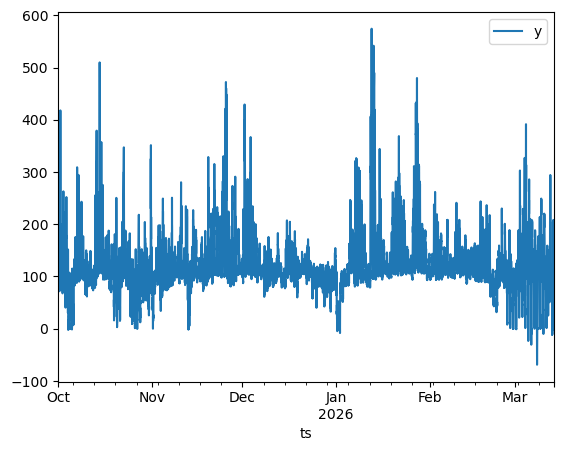

In [177]:
df[["y"]].plot()
#Missing ENTO-E data

In [178]:
# -------------------------------
# 3) Create time-based train/test split (block split)
# -------------------------------
# We split by DAY to avoid leakage across intra-day adjacency.
df["day"] = df.index.normalize()

all_days = np.array(sorted(df["day"].unique()))
if len(all_days) < (MIN_TRAIN_DAYS + TEST_DAYS):
    raise ValueError(
        f"Not enough post-breakpoint days for robust validation. "
        f"Have {len(all_days)} days, need at least {MIN_TRAIN_DAYS + TEST_DAYS}."
    )

test_days = all_days[-TEST_DAYS:]
train_days = all_days[:-TEST_DAYS]

train = df[df["day"].isin(train_days)].copy()
test  = df[df["day"].isin(test_days)].copy()

In [179]:
train

,y,hour_ts,y_hour,hod,dow,month,is_weekend,hour_ramp_24,q_in_hour,qod,delta_true,day
ts,,,,,,,,,,,,
2025-10-01 00:00:00+02:00,98.95,2025-10-01 00:00:00+02:00,93.6800,0,2,10,0,NaN,0,0,5.2700,2025-10-01 00:00:00+02:00
2025-10-01 00:15:00+02:00,91.13,2025-10-01 00:00:00+02:00,93.6800,0,2,10,0,NaN,1,1,-2.5500,2025-10-01 00:00:00+02:00
2025-10-01 00:30:00+02:00,81.79,2025-10-01 00:00:00+02:00,93.6800,0,2,10,0,NaN,2,2,-11.8900,2025-10-01 00:00:00+02:00
2025-10-01 00:45:00+02:00,102.85,2025-10-01 00:00:00+02:00,93.6800,0,2,10,0,NaN,3,3,9.1700,2025-10-01 00:00:00+02:00
2025-10-01 01:00:00+02:00,93.98,2025-10-01 01:00:00+02:00,97.9375,1,2,10,0,NaN,0,4,-3.9575,2025-10-01 00:00:00+02:00
...,...,...,...,...,...,...,...,...,...,...,...,...
2026-02-11 22:45:00+01:00,103.25,2026-02-11 22:00:00+01:00,108.3625,22,2,2,0,-8.3625,3,91,-5.1125,2026-02-11 00:00:00+01:00
2026-02-11 23:00:00+01:00,107.23,2026-02-11 23:00:00+01:00,103.3800,23,2,2,0,-1.8475,0,92,3.8500,2026-02-11 00:00:00+01:00
2026-02-11 23:15:00+01:00,101.87,2026-02-11 23:00:00+01:00,103.3800,23,2,2,0,-1.8475,1,93,-1.5100,2026-02-11 00:00:00+01:00


In [180]:
test

,y,hour_ts,y_hour,hod,dow,month,is_weekend,hour_ramp_24,q_in_hour,qod,delta_true,day
ts,,,,,,,,,,,,
2026-02-12 00:00:00+01:00,111.89,2026-02-12 00:00:00+01:00,111.890,0,3,2,0,4.0500,0,0,0.000,2026-02-12 00:00:00+01:00
2026-02-12 00:15:00+01:00,111.89,2026-02-12 00:00:00+01:00,111.890,0,3,2,0,4.0500,1,1,0.000,2026-02-12 00:00:00+01:00
2026-02-12 00:30:00+01:00,111.89,2026-02-12 00:00:00+01:00,111.890,0,3,2,0,4.0500,2,2,0.000,2026-02-12 00:00:00+01:00
2026-02-12 00:45:00+01:00,111.89,2026-02-12 00:00:00+01:00,111.890,0,3,2,0,4.0500,3,3,0.000,2026-02-12 00:00:00+01:00
2026-02-12 01:00:00+01:00,112.00,2026-02-12 01:00:00+01:00,112.445,1,3,2,0,10.1000,0,4,-0.445,2026-02-12 00:00:00+01:00
...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-13 22:45:00+01:00,116.88,2026-03-13 22:00:00+01:00,124.250,22,4,3,0,25.5225,3,91,-7.370,2026-03-13 00:00:00+01:00
2026-03-13 23:00:00+01:00,133.69,2026-03-13 23:00:00+01:00,113.430,23,4,3,0,22.7525,0,92,20.260,2026-03-13 00:00:00+01:00
2026-03-13 23:15:00+01:00,107.84,2026-03-13 23:00:00+01:00,113.430,23,4,3,0,22.7525,1,93,-5.590,2026-03-13 00:00:00+01:00


In [181]:
X_train = train[FEATURES]
y_train = train["delta_true"]

X_test  = test[FEATURES]
y_test  = test["delta_true"]

# Model: LightGBM if available, else sklearn GradientBoostingRegressor
model_name = None
model = None

model_name = "LightGBM"
model = lgb.LGBMRegressor(
        n_estimators=1200,
        learning_rate=0.03,
        num_leaves=64,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=42,
        n_jobs=-1,
    )
model.fit(X_train, y_train)

# Predict deltas, reconstruct 15-min prices
test = test.copy()
test["delta_hat"] = model.predict(X_test)
test["y_hat"] = test["y_hour"] + test["delta_hat"]
test

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000161 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 553
[LightGBM] [Info] Number of data points in the train set: 12868, number of used features: 7
[LightGBM] [Info] Start training from score 0.000000


,y,hour_ts,y_hour,hod,dow,month,is_weekend,hour_ramp_24,q_in_hour,qod,delta_true,day,delta_hat,y_hat
ts,,,,,,,,,,,,,,
2026-02-12 00:00:00+01:00,111.89,2026-02-12 00:00:00+01:00,111.890,0,3,2,0,4.0500,0,0,0.000,2026-02-12 00:00:00+01:00,2.850397,114.740397
2026-02-12 00:15:00+01:00,111.89,2026-02-12 00:00:00+01:00,111.890,0,3,2,0,4.0500,1,1,0.000,2026-02-12 00:00:00+01:00,-0.121803,111.768197
2026-02-12 00:30:00+01:00,111.89,2026-02-12 00:00:00+01:00,111.890,0,3,2,0,4.0500,2,2,0.000,2026-02-12 00:00:00+01:00,-1.212499,110.677501
2026-02-12 00:45:00+01:00,111.89,2026-02-12 00:00:00+01:00,111.890,0,3,2,0,4.0500,3,3,0.000,2026-02-12 00:00:00+01:00,-2.445968,109.444032
2026-02-12 01:00:00+01:00,112.00,2026-02-12 01:00:00+01:00,112.445,1,3,2,0,10.1000,0,4,-0.445,2026-02-12 00:00:00+01:00,2.587040,115.032040
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-13 22:45:00+01:00,116.88,2026-03-13 22:00:00+01:00,124.250,22,4,3,0,25.5225,3,91,-7.370,2026-03-13 00:00:00+01:00,-9.823685,114.426315
2026-03-13 23:00:00+01:00,133.69,2026-03-13 23:00:00+01:00,113.430,23,4,3,0,22.7525,0,92,20.260,2026-03-13 00:00:00+01:00,1.958218,115.388218
2026-03-13 23:15:00+01:00,107.84,2026-03-13 23:00:00+01:00,113.430,23,4,3,0,22.7525,1,93,-5.590,2026-03-13 00:00:00+01:00,2.001155,115.431155


In [182]:
mae = mean_absolute_error(test["y"], test["y_hat"])
rmse = float(np.sqrt(mean_squared_error(test["y"], test["y_hat"])))

# Quarter-wise errors
test["abs_err"] = (test["y"] - test["y_hat"]).abs()
mae_by_q = test.groupby("q_in_hour")["abs_err"].mean().rename("MAE")

# Spike subset: evaluate on top 1% true prices (heavy-tail behavior)
thr = test["y"].quantile(0.99)
spike = test[test["y"] >= thr]
spike_mae = mean_absolute_error(spike["y"], spike["y_hat"]) if len(spike) else np.nan
spike_rmse = float(np.sqrt(mean_squared_error(spike["y"], spike["y_hat"]))) if len(spike) else np.nan

# Distribution check (quantiles)
q_levels = [0.01, 0.05, 0.5, 0.95, 0.99]
true_q = test["y"].quantile(q_levels)
hat_q  = test["y_hat"].quantile(q_levels)
quantile_compare = pd.DataFrame({"true": true_q, "recon": hat_q})
quantile_compare.index.name = "quantile"
quantile_compare["diff"] = quantile_compare["true"] - quantile_compare["recon"]

print("\n============================")
print("PHASE 2: Proxy reconstruction validation (hourly → 15-min)")
print("============================")
print(f"Country: {COUNTRY}")
print(f"Model: {model_name}")
print(f"Train days: {train_days[0].date()} → {train_days[-1].date()}  ({len(train_days)} days)")
print(f"Test  days: {test_days[0].date()} → {test_days[-1].date()}   ({len(test_days)} days)")
print(f"\nOverall MAE : {mae:.4f}")
print(f"Overall RMSE: {rmse:.4f}")
print("\nMAE by quarter-in-hour (0..3):")
print(mae_by_q)

print("\nSpike subset (top 1% of TRUE prices in test):")
print(f"Threshold (99th pct): {thr:.3f}")
print(f"Spike count: {len(spike)}")
print(f"Spike MAE : {spike_mae:.4f}")
print(f"Spike RMSE: {spike_rmse:.4f}")

print("\nQuantile comparison (TRUE vs reconstructed):")
print(quantile_compare)

# Optional: error by quarter-of-day (shape quality across day)
mae_by_qod = test.groupby("qod")["abs_err"].mean()
print("\nMAE by quarter-of-day computed (length):", len(mae_by_qod))


PHASE 2: Proxy reconstruction validation (hourly → 15-min)
Country: PL
Model: LightGBM
Train days: 2025-10-01 → 2026-02-11  (134 days)
Test  days: 2026-02-12 → 2026-03-13   (30 days)

Overall MAE : 6.4753
Overall RMSE: 12.0778

MAE by quarter-in-hour (0..3):
q_in_hour
0    8.763698
1    4.092865
2    3.995392
3    9.049059
Name: MAE, dtype: float64

Spike subset (top 1% of TRUE prices in test):
Threshold (99th pct): 237.098
Spike count: 29
Spike MAE : 35.5413
Spike RMSE: 54.0697

Quantile comparison (TRUE vs reconstructed):
              true       recon      diff
quantile                                
0.01       -3.0536   -6.270198  3.216598
0.05        1.5775   10.210122 -8.632622
0.50      102.8250  103.804641 -0.979641
0.95      185.6135  183.204023  2.409477
0.99      237.0975  240.478619 -3.381119

MAE by quarter-of-day computed (length): 96


In [183]:
# -----------------------
# Helper: DST-safe hour bucket key for 15-min timestamps
# -----------------------
def hour_bucket_local(idx: pd.DatetimeIndex, tz: str = TZ) -> pd.DatetimeIndex:
    """Return hour bucket timestamps in local tz, computed by flooring in UTC (DST-safe)."""
    return idx.tz_convert("UTC").floor("H").tz_convert(tz)

In [184]:
# -----------------------
# 1) Build training set from TRUE 15-min data (post-breakpoint)
# -----------------------
g = PHASE1_GRID.copy()
g = g[g["is_observed"]].copy()

# Prefer the true 15-min post-breakpoint part
if "resolution" in g.columns:
    g15 = g[(g.index >= BREAKPOINT) & (g["resolution"] == "15min")].copy()
else:
    g15 = g[g.index >= BREAKPOINT].copy()

g15 = g15.sort_index()
g15 = g15[["y"]].dropna()

if g15.empty:
    raise ValueError("No observed 15-min data found after 2025-10-01. Check Phase 1 grid and breakpoint.")

# Hourly mean series derived from TRUE 15-min (simulated hourly-only)
hour = g15["y"].resample("1H").mean().to_frame("y_hour")
hour["hod"] = hour.index.hour.astype(int)
hour["dow"] = hour.index.dayofweek.astype(int)
hour["month"] = hour.index.month.astype(int)
hour["is_weekend"] = (hour["dow"] >= 5).astype(int)
hour["hour_ramp_1"] = hour["y_hour"].diff(1)
hour["hour_ramp_24"] = hour["y_hour"].diff(24)

# Align hourly-only info to each 15-min timestamp
train_df = g15.copy()
train_df["hour_ts"] = hour_bucket_local(train_df.index)  # DST-safe hour key
train_df = train_df.join(hour, on="hour_ts", how="left")

train_df["q_in_hour"] = (train_df.index.minute // 15).astype(int)  # 0..3
train_df["delta_true"] = train_df["y"] - train_df["y_hour"]

FEATURES = [
    "y_hour", "hour_ramp_1", "hour_ramp_24",
    "hod", "dow", "month", "is_weekend",
    "q_in_hour",
]

train_df = train_df.dropna(subset=FEATURES + ["delta_true"]).copy()

In [185]:
def fit_quantile(alpha: float):
    m = lgb.LGBMRegressor(
        objective="quantile",
        alpha=alpha,
        n_estimators=1400,
        learning_rate=0.03,
        num_leaves=64,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=42,
        n_jobs=-1,
    )
    m.fit(train_df[FEATURES], train_df["delta_true"])
    return m

q10_model = fit_quantile(0.10)
q50_model = fit_quantile(0.50)  # use as point estimate (robust)
q90_model = fit_quantile(0.90)

PHASE3_QMODELS = {"p10": q10_model, "p50": q50_model, "p90": q90_model}
PHASE3_FEATURES = FEATURES

print("Phase 3: trained quantile disaggregation models on post-breakpoint TRUE 15-min data.")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000158 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 809
[LightGBM] [Info] Number of data points in the train set: 15652, number of used features: 8
[LightGBM] [Info] Start training from score -11.961499
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000174 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 809
[LightGBM] [Info] Number of data points in the train set: 15652, number of used features: 8
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000152 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info]

In [186]:
PHASE1_RAW

,start,end,y,source_file,delta_min,resolution
0,2024-01-01 00:00:00+01:00,2024-01-01 01:00:00+01:00,76.69,Entso_e\PL\DA_price\GUI_ENERGY_PRICES_20231231...,60.0,60min
1,2024-01-01 01:00:00+01:00,2024-01-01 02:00:00+01:00,74.50,Entso_e\PL\DA_price\GUI_ENERGY_PRICES_20231231...,60.0,60min
2,2024-01-01 02:00:00+01:00,2024-01-01 03:00:00+01:00,73.29,Entso_e\PL\DA_price\GUI_ENERGY_PRICES_20231231...,60.0,60min
3,2024-01-01 03:00:00+01:00,2024-01-01 04:00:00+01:00,71.58,Entso_e\PL\DA_price\GUI_ENERGY_PRICES_20231231...,60.0,60min
4,2024-01-01 04:00:00+01:00,2024-01-01 05:00:00+01:00,73.27,Entso_e\PL\DA_price\GUI_ENERGY_PRICES_20231231...,60.0,60min
...,...,...,...,...,...,...
50731,2026-03-13 22:45:00+01:00,2026-03-13 23:00:00+01:00,116.88,Entso_e\PL\DA_price\GUI_ENERGY_PRICES_20251231...,15.0,15min
50732,2026-03-13 23:00:00+01:00,2026-03-13 23:15:00+01:00,133.69,Entso_e\PL\DA_price\GUI_ENERGY_PRICES_20251231...,15.0,15min
50733,2026-03-13 23:15:00+01:00,2026-03-13 23:30:00+01:00,107.84,Entso_e\PL\DA_price\GUI_ENERGY_PRICES_20251231...,15.0,15min
50734,2026-03-13 23:30:00+01:00,2026-03-13 23:45:00+01:00,108.84,Entso_e\PL\DA_price\GUI_ENERGY_PRICES_20251231...,15.0,15min


In [187]:
# -----------------------
# 3) Extract PRE-breakpoint hourly observations (the thing we backcast from)
# -----------------------
raw = PHASE1_RAW.copy()

# Determine hourly rows: delta_min ~ 60 and start < breakpoint
if "delta_min" not in raw.columns:
    raw["delta_min"] = (raw["end"] - raw["start"]).dt.total_seconds() / 60.0
    
pre_hour = raw[(raw["start"] < BREAKPOINT)].copy()
pre_hour = pre_hour.sort_values("start")

if pre_hour.empty:
    raise ValueError(
        "No pre-breakpoint hourly observations found (delta_min≈60). "
        "If your pre-breakpoint data is not hourly in PHASE1_RAW, check Phase 1 ingestion."
    )

# Create hourly series
pre_hour = pre_hour.set_index("start")[["y"]].rename(columns={"y": "y_hour"})
pre_hour.index.name = "hour_ts"

# Build a continuous hourly index (DST-safe): do in UTC then convert back
hour_utc = pd.date_range(
    pre_hour.index.min().tz_convert("UTC"),
    pre_hour.index.max().tz_convert("UTC"),
    freq="1H",
    tz="UTC",
)
hour_local = hour_utc.tz_convert(TZ)

pre_hour = pre_hour.reindex(hour_local)
pre_hour["is_hour_observed"] = pre_hour["y_hour"].notna()

# For backcasting we typically need all hours; if there are gaps, we can:
# - leave them NaN (synthetic will be NaN for those hours)
# - or interpolate hourly. For publication safety, default to NO interpolation.
# If you want interpolation, do it explicitly and document it.

# Hourly features
pre_hour["hod"] = pre_hour.index.hour.astype(int)
pre_hour["dow"] = pre_hour.index.dayofweek.astype(int)
pre_hour["month"] = pre_hour.index.month.astype(int)
pre_hour["is_weekend"] = (pre_hour["dow"] >= 5).astype(int)
pre_hour["hour_ramp_1"] = pre_hour["y_hour"].diff(1)
pre_hour["hour_ramp_24"] = pre_hour["y_hour"].diff(24)

In [188]:
pre_hour

,y_hour,is_hour_observed,hod,dow,month,is_weekend,hour_ramp_1,hour_ramp_24
2024-01-01 00:00:00+01:00,76.69,True,0,0,1,0,NaN,NaN
2024-01-01 01:00:00+01:00,74.50,True,1,0,1,0,-2.19,NaN
2024-01-01 02:00:00+01:00,73.29,True,2,0,1,0,-1.21,NaN
2024-01-01 03:00:00+01:00,71.58,True,3,0,1,0,-1.71,NaN
2024-01-01 04:00:00+01:00,73.27,True,4,0,1,0,1.69,NaN
...,...,...,...,...,...,...,...,...
2025-09-30 19:00:00+02:00,393.74,True,19,1,9,0,127.43,-15.67
2025-09-30 20:00:00+02:00,138.96,True,20,1,9,0,-254.78,-26.23
2025-09-30 21:00:00+02:00,107.27,True,21,1,9,0,-31.69,-14.14
2025-09-30 22:00:00+02:00,100.65,True,22,1,9,0,-6.62,-2.80


In [189]:
# -----------------------
# 4) Expand each hour into 4 quarters (DST-safe, generate in UTC then convert)
# -----------------------
# Create quarter timestamps for each hour in UTC, then convert to local tz
pre_hour_utc = pre_hour.index.tz_convert("UTC")

quarters_utc = []
q_in_hour = []
hour_key_utc = []

for q, minutes in enumerate([0, 15, 30, 45]):
    quarters_utc.append(pre_hour_utc + pd.Timedelta(minutes=minutes))
    q_in_hour.append(np.full(len(pre_hour_utc), q, dtype=int))
    hour_key_utc.append(pre_hour_utc)  # hour bucket key in UTC

quarters_utc = pd.DatetimeIndex(np.concatenate(quarters_utc))
q_in_hour = np.concatenate(q_in_hour)
hour_key_utc = pd.DatetimeIndex(np.concatenate(hour_key_utc))

synthetic = pd.DataFrame({
    "ts_utc": quarters_utc,
    "hour_ts_utc": hour_key_utc,
    "q_in_hour": q_in_hour
}).sort_values("ts_utc")

test_synth = pre_hour.copy()

# Convert to local tz for final index
synthetic["ts"] = synthetic["ts_utc"].dt.tz_convert(TZ)
synthetic["hour_ts"] = synthetic["hour_ts_utc"].dt.tz_convert(TZ)

# Join hourly features/price onto each quarter
synthetic = synthetic.join(pre_hour, on="hour_ts", how="left")

# Prepare feature matrix and predict delta quantiles
X_syn = synthetic[FEATURES]

# Predict deltas (will be NaN where hourly y_hour is NaN)
synthetic["delta_p10"] = np.where(
    synthetic["y_hour"].notna(),
    q10_model.predict(X_syn),
    np.nan
)
synthetic["delta_p50"] = np.where(
    synthetic["y_hour"].notna(),
    q50_model.predict(X_syn),
    np.nan
)
synthetic["delta_p90"] = np.where(
    synthetic["y_hour"].notna(),
    q90_model.predict(X_syn),
    np.nan
)

# Reconstruct price quantiles
synthetic["y_p10"] = synthetic["y_hour"] + synthetic["delta_p10"]
synthetic["y_p50"] = synthetic["y_hour"] + synthetic["delta_p50"]  # point estimate
synthetic["y_p90"] = synthetic["y_hour"] + synthetic["delta_p90"]

synthetic["is_synthetic"] = 1
synthetic["is_observed"] = 0

# Keep clean output
SYNTH_15M_PRE = synthetic.set_index("ts")[["y_p10", "y_p50", "y_p90", "is_synthetic", "is_observed"]].sort_index()

print("Phase 3: generated pre-breakpoint synthetic 15-min series with P10/P50/P90.")
print("Synthetic range:", SYNTH_15M_PRE.index.min(), "→", SYNTH_15M_PRE.index.max())
print("Synthetic rows:", len(SYNTH_15M_PRE))
print(SYNTH_15M_PRE)

Phase 3: generated pre-breakpoint synthetic 15-min series with P10/P50/P90.
Synthetic range: 2024-01-01 00:00:00+01:00 → 2025-09-30 23:45:00+02:00
Synthetic rows: 61340
                               y_p10       y_p50       y_p90  is_synthetic  \
ts                                                                           
2024-01-01 00:00:00+01:00  75.180990   79.765885   87.071283             1   
2024-01-01 00:15:00+01:00  74.645508   77.559688   80.697432             1   
2024-01-01 00:30:00+01:00  71.880785   75.476814   78.563517             1   
2024-01-01 00:45:00+01:00  68.604399   74.523358   78.652258             1   
2024-01-01 01:00:00+01:00  73.172940   77.096449   81.090876             1   
...                              ...         ...         ...           ...   
2025-09-30 22:45:00+02:00  88.196511   93.846569   98.936352             1   
2025-09-30 23:00:00+02:00  94.685268  102.022245  104.893916             1   
2025-09-30 23:15:00+02:00  90.582770   94.944093   

In [190]:
test_synth

,y_hour,is_hour_observed,hod,dow,month,is_weekend,hour_ramp_1,hour_ramp_24
2024-01-01 00:00:00+01:00,76.69,True,0,0,1,0,NaN,NaN
2024-01-01 01:00:00+01:00,74.50,True,1,0,1,0,-2.19,NaN
2024-01-01 02:00:00+01:00,73.29,True,2,0,1,0,-1.21,NaN
2024-01-01 03:00:00+01:00,71.58,True,3,0,1,0,-1.71,NaN
2024-01-01 04:00:00+01:00,73.27,True,4,0,1,0,1.69,NaN
...,...,...,...,...,...,...,...,...
2025-09-30 19:00:00+02:00,393.74,True,19,1,9,0,127.43,-15.67
2025-09-30 20:00:00+02:00,138.96,True,20,1,9,0,-254.78,-26.23
2025-09-30 21:00:00+02:00,107.27,True,21,1,9,0,-31.69,-14.14
2025-09-30 22:00:00+02:00,100.65,True,22,1,9,0,-6.62,-2.80


In [191]:
# -----------------------
# 5) (Optional) Build unified 15-min dataset: pre synthetic + post real
# -----------------------
# Use P50 as the single point price for synthetic history.
POST_REAL_15M = PHASE1_GRID.loc[PHASE1_GRID["is_observed"] & (PHASE1_GRID.index >= BREAKPOINT), ["y"]].copy()
POST_REAL_15M = POST_REAL_15M.rename(columns={"y": "y_real"})
POST_REAL_15M["is_synthetic"] = 0
POST_REAL_15M["is_observed"] = 1

# Create a unified point series "y_point" (synthetic uses y_p50; real uses y_real)
pre_point = SYNTH_15M_PRE.copy()
pre_point["y_point"] = pre_point["y_p50"]

post_point = POST_REAL_15M.copy()
post_point["y_point"] = post_point["y_real"]
post_point["y_p10"] = np.nan
post_point["y_p50"] = np.nan
post_point["y_p90"] = np.nan

UNIFIED_15M = pd.concat([
    pre_point[["y_point", "y_p10", "y_p50", "y_p90", "is_synthetic", "is_observed"]],
    post_point[["y_point", "y_p10", "y_p50", "y_p90", "is_synthetic", "is_observed"]],
]).sort_index()

PHASE3_SYNTH_15M_PRE = SYNTH_15M_PRE
PHASE3_UNIFIED_15M = UNIFIED_15M

print("\nPhase 3 complete. Objects in memory:")
print(" - PHASE3_QMODELS (dict of quantile models)")
print(" - PHASE3_SYNTH_15M_PRE (pre-breakpoint synthetic 15-min with P10/P50/P90)")
print(" - PHASE3_UNIFIED_15M (unified 15-min point series + bands where available)")
PHASE3_UNIFIED_15M


Phase 3 complete. Objects in memory:
 - PHASE3_QMODELS (dict of quantile models)
 - PHASE3_SYNTH_15M_PRE (pre-breakpoint synthetic 15-min with P10/P50/P90)
 - PHASE3_UNIFIED_15M (unified 15-min point series + bands where available)


,y_point,y_p10,y_p50,y_p90,is_synthetic,is_observed
ts,,,,,,
2024-01-01 00:00:00+01:00,79.765885,75.180990,79.765885,87.071283,1,0
2024-01-01 00:15:00+01:00,77.559688,74.645508,77.559688,80.697432,1,0
2024-01-01 00:30:00+01:00,75.476814,71.880785,75.476814,78.563517,1,0
2024-01-01 00:45:00+01:00,74.523358,68.604399,74.523358,78.652258,1,0
2024-01-01 01:00:00+01:00,77.096449,73.172940,77.096449,81.090876,1,0
...,...,...,...,...,...,...
2026-03-13 22:45:00+01:00,116.880000,NaN,NaN,NaN,0,1
2026-03-13 23:00:00+01:00,133.690000,NaN,NaN,NaN,0,1
2026-03-13 23:15:00+01:00,107.840000,NaN,NaN,NaN,0,1


In [192]:
df[df.index.duplicated()]

,y,hour_ts,y_hour,hod,dow,month,is_weekend,hour_ramp_24,q_in_hour,qod,delta_true,day
ts,,,,,,,,,,,,


In [193]:
# ----------------------------
# Load parsing helpers (CET/CEST label -> unambiguous instant)
# ----------------------------
def parse_dt_with_label(s: str, file_type: str) -> pd.Timestamp:
    """
    Input: '31/03/2024 01:00:00 (CET)' or '(CEST)'
    Return: tz-aware timestamp in Europe/Budapest (as an instant).
    """
    s = s.strip()
    m = re.match(r"^(.*?)(?:\s+\((CET|CEST)\))?$", s)
    if not m:
        raise ValueError(f"Unrecognized datetime format: {s}")
    dt_part = m.group(1).strip()
    label = m.group(2)

    if file_type == "load":
        dt = pd.to_datetime(dt_part, format="%d/%m/%Y %H:%M", errors="raise")
    elif file_type == "renew":
        dt = pd.to_datetime(dt_part, format="%d/%m/%Y %H:%M:%S", errors="raise")

    if label is None:
        # fallback: attach TZ conservatively (rare for ENTSO-E exports)
        return dt.tz_localize(TZ, ambiguous="NaT", nonexistent="shift_forward")

    offset_hours = 1 if label == "CET" else 2  # CET=UTC+1, CEST=UTC+2
    utc = (dt - pd.Timedelta(hours=offset_hours)).tz_localize("UTC")
    return utc.tz_convert(TZ)

def parse_mtu_start_load(mtu: str) -> pd.Timestamp:
    # "dd/mm/YYYY HH:MM:SS (CET) - dd/mm/YYYY HH:MM:SS (CET)"
    a = mtu.split("-")[0].strip()
    return parse_dt_with_label(a, file_type="load")

def parse_mtu_start_renew(mtu: str) -> pd.Timestamp:
    # "dd/mm/YYYY HH:MM:SS (CET) - dd/mm/YYYY HH:MM:SS (CET)"
    a = mtu.split("-")[0].strip()
    return parse_dt_with_label(a, file_type="renew")

def pick_load_col(df: pd.DataFrame) -> str:
    # Try common ENTSO-E export column names
    print(df)
    candidates = [
        "Total Load Forecast (MW)",
        "Total Load Forecast (MWh)",
        "Total Load Forecast (MW )",
        "Total Load (MW)",
        "Value",
    ]
    for c in candidates:
        if c in df.columns:
            return c
    # fallback: pick first numeric-like column not MTU/Area
    non = {MTU_COL, "Area", "Bidding Zone", "Country"}
    for c in df.columns:
        if c in non: 
            continue
        if df[c].dtype != object:
            return c
    raise ValueError(f"Could not identify load column. Columns: {list(df.columns)}")

#Load Forecast

def load_total_load_forecast(paths) -> pd.Series:
    parts = []
    for p in paths:
        df = pd.read_csv(p)
        if MTU_COL not in df.columns:
            raise ValueError(f"Missing '{MTU_COL}' in {p}")

        # Filter HU if applicable
        if "Area" in df.columns:
            hu_mask = df["Area"].astype(str).str.contains(r"\bHU\b|Hungary", case=False, na=False)
            if hu_mask.any():
                df = df.loc[hu_mask].copy()
        col = "Day-ahead Total Load Forecast (MW)"

        ts = df[MTU_COL].astype(str).map(parse_mtu_start_load)
        vals = pd.to_numeric(df[col], errors="coerce")

        tmp = pd.DataFrame({"ts": ts, "load_fc": vals}).dropna()
        parts.append(tmp)

    all_df = pd.concat(parts, ignore_index=True).drop_duplicates(subset=["ts"]).sort_values("ts")
    s = all_df.set_index("ts")["load_fc"].sort_index()
    return s
def load_total_generation_forecast(paths) ->pd.Series:
    parts = []
    for p in paths:
        df = pd.read_csv(p)
        if MTU_COL not in df.columns:
            raise ValueError(f"Missing '{MTU_COL}' in {p}")

        # Filter HU if applicable
        if "Area" in df.columns:
            hu_mask = df["Area"].astype(str).str.contains(r"\bHU\b|Hungary", case=False, na=False)
            if hu_mask.any():
                df = df.loc[hu_mask].copy()
        
        col = "Generation Forecast (MW)"
        ts = df[MTU_COL].astype(str).map(parse_mtu_start_renew)
        vals = pd.to_numeric(df[col], errors="coerce")

        tmp = pd.DataFrame({"ts": ts, "renew_fc": vals}).dropna()
        parts.append(tmp)

    all_df = pd.concat(parts, ignore_index=True).drop_duplicates(subset=["ts"]).sort_values("ts")
    s = all_df.set_index("ts")["renew_fc"].sort_index()
    return s

def load_renewables_forecast(paths, renew_type: str) ->pd.Series:
    parts = []
    for p in paths:
        df = pd.read_csv(p)
        if MTU_COL not in df.columns:
            raise ValueError(f"Missing '{MTU_COL}' in {p}")

        # Filter HU if applicable
        if "Area" in df.columns:
            hu_mask = df["Area"].astype(str).str.contains(r"\bHU\b|Hungary", case=False, na=False)
            if hu_mask.any():
                df = df.loc[hu_mask].copy()
        col = "Day-ahead (MW)"
        ts = df[MTU_COL].astype(str).map(parse_mtu_start_renew)
        vals = pd.to_numeric(df[col], errors="coerce")
        if renew_type == "solar":
            tmp = pd.DataFrame({"ts": ts, "renew_fc_solar": vals}).dropna()
        elif renew_type == "wind":
            tmp = pd.DataFrame({"ts": ts, "renew_fc_wind": vals}).dropna()
        parts.append(tmp)

    all_df = pd.concat(parts, ignore_index=True).drop_duplicates(subset=["ts"]).sort_values("ts")
    if renew_type == "solar":
        s = all_df.set_index("ts")["renew_fc_solar"].sort_index()
    elif renew_type == "wind":
        s = all_df.set_index("ts")["renew_fc_wind"].sort_index()
    return s

In [194]:
load_fc = load_total_load_forecast(LOAD_FILES)
load_fc = load_fc[load_fc.index < STUDYBREAK]
print("Loaded load forecast:", load_fc.index.min(), "→", load_fc.index.max(), "rows:", len(load_fc))
print(load_fc)

Loaded load forecast: 2024-01-01 00:00:00+01:00 → 2026-03-13 23:45:00+01:00 rows: 50736
ts
2024-01-01 00:00:00+01:00    14899.0
2024-01-01 01:00:00+01:00    14425.0
2024-01-01 02:00:00+01:00    13744.0
2024-01-01 03:00:00+01:00    13363.0
2024-01-01 04:00:00+01:00    13181.0
                              ...   
2026-03-13 22:45:00+01:00    17600.0
2026-03-13 23:00:00+01:00    17350.0
2026-03-13 23:15:00+01:00    17000.0
2026-03-13 23:30:00+01:00    16650.0
2026-03-13 23:45:00+01:00    16350.0
Name: load_fc, Length: 50736, dtype: float64


In [195]:
renewables_solar_fc = load_renewables_forecast(RENEWABLES_FILES_SOLAR, "solar")
renewables_solar_fc = renewables_solar_fc[renewables_solar_fc.index < STUDYBREAK]
print("Loaded load forecast:", renewables_solar_fc.index.min(), "→", renewables_solar_fc.index.max(), "rows:", len(renewables_solar_fc))
print(renewables_solar_fc)

Loaded load forecast: 2024-01-01 00:00:00+01:00 → 2026-03-13 23:45:00+01:00 rows: 50736
ts
2024-01-01 00:00:00+01:00    0.0
2024-01-01 01:00:00+01:00    0.0
2024-01-01 02:00:00+01:00    0.0
2024-01-01 03:00:00+01:00    0.0
2024-01-01 04:00:00+01:00    0.0
                            ... 
2026-03-13 22:45:00+01:00    0.0
2026-03-13 23:00:00+01:00    0.0
2026-03-13 23:15:00+01:00    0.0
2026-03-13 23:30:00+01:00    0.0
2026-03-13 23:45:00+01:00    0.0
Name: renew_fc_solar, Length: 50736, dtype: float64


In [196]:
renewables_wind_fc = load_renewables_forecast(RENEWABLES_FILES_WIND, "wind")
renewables_wind_fc = renewables_wind_fc[renewables_wind_fc.index < STUDYBREAK]
print("Loaded load forecast:", renewables_wind_fc.index.min(), "→", renewables_wind_fc.index.max(), "rows:", len(renewables_wind_fc))
print(renewables_wind_fc)

Loaded load forecast: 2024-01-01 00:00:00+01:00 → 2026-03-13 23:45:00+01:00 rows: 50736
ts
2024-01-01 00:00:00+01:00    2782.58
2024-01-01 01:00:00+01:00    2576.21
2024-01-01 02:00:00+01:00    2413.94
2024-01-01 03:00:00+01:00    2273.01
2024-01-01 04:00:00+01:00    2117.32
                              ...   
2026-03-13 22:45:00+01:00    5957.84
2026-03-13 23:00:00+01:00    5929.00
2026-03-13 23:15:00+01:00    5904.06
2026-03-13 23:30:00+01:00    5861.89
2026-03-13 23:45:00+01:00    5821.07
Name: renew_fc_wind, Length: 50736, dtype: float64


In [197]:
# ----------------------------
# 1) Prepare unified series
# ----------------------------
u = PHASE3_UNIFIED_15M.copy().sort_index()
need_cols = {"y_point", "is_synthetic", "is_observed"}
missing = need_cols - set(u.columns)
if missing:
    raise ValueError(f"PHASE3_UNIFIED_15M missing columns: {missing}")
u["load_fc"] = load_fc.reindex(u.index)
u["renewables_solar_fc"] = renewables_solar_fc.reindex(u.index)
u["renewables_wind_fc"] = renewables_wind_fc.reindex(u.index)
# Ensure index tz-aware in Budapest
if u.index.tz is None:
    raise ValueError("PHASE3_UNIFIED_15M index must be tz-aware (Europe/Budapest).")

real = u[u.index >= "2025-10-01 00:00"]

In [198]:
u

,y_point,y_p10,y_p50,y_p90,is_synthetic,is_observed,load_fc,renewables_solar_fc,renewables_wind_fc
ts,,,,,,,,,
2024-01-01 00:00:00+01:00,79.765885,75.180990,79.765885,87.071283,1,0,14899.0,0.0,2782.58
2024-01-01 00:15:00+01:00,77.559688,74.645508,77.559688,80.697432,1,0,NaN,NaN,NaN
2024-01-01 00:30:00+01:00,75.476814,71.880785,75.476814,78.563517,1,0,NaN,NaN,NaN
2024-01-01 00:45:00+01:00,74.523358,68.604399,74.523358,78.652258,1,0,NaN,NaN,NaN
2024-01-01 01:00:00+01:00,77.096449,73.172940,77.096449,81.090876,1,0,14425.0,0.0,2576.21
...,...,...,...,...,...,...,...,...,...
2026-03-13 22:45:00+01:00,116.880000,NaN,NaN,NaN,0,1,17600.0,0.0,5957.84
2026-03-13 23:00:00+01:00,133.690000,NaN,NaN,NaN,0,1,17350.0,0.0,5929.00
2026-03-13 23:15:00+01:00,107.840000,NaN,NaN,NaN,0,1,17000.0,0.0,5904.06


In [199]:
real

,y_point,y_p10,y_p50,y_p90,is_synthetic,is_observed,load_fc,renewables_solar_fc,renewables_wind_fc
ts,,,,,,,,,
2025-10-01 00:00:00+02:00,98.95,NaN,NaN,NaN,0,1,15700.0,0.0,1668.94
2025-10-01 00:15:00+02:00,91.13,NaN,NaN,NaN,0,1,15550.0,0.0,1660.13
2025-10-01 00:30:00+02:00,81.79,NaN,NaN,NaN,0,1,15400.0,0.0,1642.44
2025-10-01 00:45:00+02:00,102.85,NaN,NaN,NaN,0,1,15200.0,0.0,1627.20
2025-10-01 01:00:00+02:00,93.98,NaN,NaN,NaN,0,1,15000.0,0.0,1604.57
...,...,...,...,...,...,...,...,...,...
2026-03-13 22:45:00+01:00,116.88,NaN,NaN,NaN,0,1,17600.0,0.0,5957.84
2026-03-13 23:00:00+01:00,133.69,NaN,NaN,NaN,0,1,17350.0,0.0,5929.00
2026-03-13 23:15:00+01:00,107.84,NaN,NaN,NaN,0,1,17000.0,0.0,5904.06


In [200]:
# ----------------------------
# 1) Build "daily cutoff table": one row per day with state features at t0 = day-1 23:45
#    and targets: the 96 prices for that day
# ----------------------------
def day_horizon_index(day: pd.Timestamp) -> pd.DatetimeIndex:
    """Return the 96 timestamps for a given local day (00:00..23:45)."""
    start = pd.Timestamp(day)
    return pd.date_range(start, start + pd.Timedelta(hours=24) - pd.Timedelta(minutes=15),
                         freq="15min", tz=TZ)

In [201]:
def compute_state_features_at_t0(series: pd.Series, t0: pd.Timestamp) -> dict:
    """
    Compute state features using only history up to and including t0.
    series: y_point indexed by 15-min timestamps
    """
    feats = {}
    y0 = series.loc[:t0]
    feats["last_y"] = float(y0.iloc[-1])
    # Lags at cutoff
    for L in STATE_LAGS:
        key = f"lag_{L}_t0"
        feats[key] = float(y0.iloc[-(L+1)])  # because y0.iloc[-1] is t0

    # Ramps at cutoff (examples)
    feats["ramp_1h_t0"] = feats["last_y"] - feats["lag_4_t0"]
    feats["ramp_6h_t0"] = feats["last_y"] - feats["lag_24_t0"]
    feats["ramp_1d_t0"] = feats["last_y"] - feats["lag_96_t0"]

    # Rolling stats ending at t0 (past values including t0)
    yvals = y0.values
    for w in STATE_ROLL_WINS:
        window = yvals[-w:]
        feats[f"roll_mean_{w}_t0"] = float(np.mean(window))
        feats[f"roll_std_{w}_t0"] = float(np.std(window, ddof=1)) if w > 1 else 0.0

    return feats

In [202]:
def build_daily_dataset(u_df: pd.DataFrame) -> pd.DataFrame:
    y = u_df["y_point"]
    lf = u_df["load_fc"]
    sf = u_df["renewables_solar_fc"]
    wf = u_df["renewables_wind_fc"]

    days = np.array(sorted(u_df.index.normalize().unique()))

    rows = []
    max_lag = max(STATE_LAGS)

    for day in days:
        day = pd.Timestamp(day)  # keep tz as-is
        h_idx = day_horizon_index(day)

        # bounds check
        if h_idx.min() < u_df.index.min() or h_idx.max() > u_df.index.max():
            continue

        t0 = (pd.Timestamp(day) - pd.Timedelta(minutes=15))
        if t0 not in y.index:
            continue

        hist_slice = y.loc[:t0]
        if len(hist_slice) < (max_lag + 2):
            continue

        state = compute_state_features_at_t0(y, t0)

        # Day-level load summary (same across 96 horizons; safe because it's forecast)
        load_day = lf.loc[h_idx]
        load_day_mean = float(load_day.mean())
        load_day_max = float(load_day.max())
        load_day_min = float(load_day.min())

        day_flags = u_df.loc[h_idx, ["is_synthetic", "is_observed"]].copy()

        # per-horizon rows
        for h, ts in enumerate(h_idx, start=1):
            r = dict(state)
            #r = dict()


            # raw horizon descriptors
            q_in_hour = int(ts.minute // 15)                  # 0..3
            qod = int(ts.hour * 4 + (ts.minute // 15))       # 0..95
            hod = int(ts.hour)                               # 0..23
            dow = int(ts.dayofweek)                          # 0..6
            month = int(ts.month)                            # 1..12


            r["h"] = h
            r["q_in_hour_target"] = q_in_hour
            r["qod_target"] = qod
            r["hod_target"] = hod
            r["dow_target"] = dow
            r["month_target"] = month
            r["is_weekend_target"] = int(dow >= 5)

            # cyclical encodings
            r["q_in_hour_sin"] = np.sin(2 * np.pi * q_in_hour / 4)
            r["q_in_hour_cos"] = np.cos(2 * np.pi * q_in_hour / 4)

            r["qod_sin"] = np.sin(2 * np.pi * qod / 96)
            r["qod_cos"] = np.cos(2 * np.pi * qod / 96)

            r["hod_sin"] = np.sin(2 * np.pi * hod / 24)
            r["hod_cos"] = np.cos(2 * np.pi * hod / 24)

            r["dow_sin"] = np.sin(2 * np.pi * dow / 7)
            r["dow_cos"] = np.cos(2 * np.pi * dow / 7)

            # month is 1..12 -> shift to 0..11 before encoding
            month0 = month - 1
            r["month_sin"] = np.sin(2 * np.pi * month0 / 12)
            r["month_cos"] = np.cos(2 * np.pi * month0 / 12)

            # load forecast features (vary by horizon)
            r["load_fc_target"] = float(lf.loc[ts])
            r["renewables_wind_fc"] = float(wf.loc[ts])
            r["renewables_solar_fc"] = float(sf.loc[ts])
            # within-day load ramps (safe; forecast curve is known)
            # use past within-forecast-day values, which are still known because the entire forecast curve is known
            prev_1h_ts = ts - pd.Timedelta(hours=1)
            prev_6h_ts = ts - pd.Timedelta(hours=6)
            prev_12h_ts = ts - pd.Timedelta(hours=12)
            r["load_ramp_1h_target"] = float(lf.loc[ts] - (lf.loc[prev_1h_ts] if prev_1h_ts in lf.index else lf.loc[ts]))
            r["load_ramp_6h_target"] = float(lf.loc[ts] - (lf.loc[prev_6h_ts] if prev_6h_ts in lf.index else lf.loc[ts]))
            r["load_ramp_12h_target"] = float(lf.loc[ts] - (lf.loc[prev_12h_ts] if prev_12h_ts in lf.index else lf.loc[ts]))

            # day-level load stats
            r["load_day_mean"] = load_day_mean
            r["load_day_max"] = load_day_max
            r["load_day_min"] = load_day_min

            # targets/labels
            r["y_target"] = float(y.loc[ts])
            r["is_synthetic"] = int(day_flags.loc[ts, "is_synthetic"])
            r["is_observed"] = int(day_flags.loc[ts, "is_observed"])
            r["day"] = pd.Timestamp(day)
            r["ts"] = ts
            rows.append(r)

    

    ds = pd.DataFrame(rows).set_index("ts").sort_index()
    for L in STATE_LAGS:
        key = f"lag_{L}_t0"
        if L in [96, 192, 672]:
            ds[key] = ds["y_target"].shift(L) 
    return ds

In [203]:
ds = build_daily_dataset(u)
ds = ds.dropna(subset=FEATURE_COLS + ["y_target"]).copy()
ds



,last_y,lag_1_t0,lag_4_t0,lag_8_t0,lag_24_t0,lag_96_t0,lag_192_t0,lag_672_t0,ramp_1h_t0,ramp_6h_t0,...,load_ramp_1h_target,load_ramp_6h_target,load_ramp_12h_target,load_day_mean,load_day_max,load_day_min,y_target,is_synthetic,is_observed,day
ts,,,,,,,,,,,,,,,,,,,,,
2024-01-16 00:00:00+01:00,81.992363,85.544411,85.719801,86.141268,105.091213,71.742427,69.261853,91.198976,-3.727438,-23.09885,...,-1140.0,-5905.0,-6219.0,23924.833333,26804.0,18713.0,86.064587,1,0,2024-01-16 00:00:00+01:00
2024-01-16 01:00:00+01:00,81.992363,85.544411,85.719801,86.141268,105.091213,69.596423,68.014048,91.374872,-3.727438,-23.09885,...,-465.0,-6348.0,-6897.0,23924.833333,26804.0,18713.0,83.192728,1,0,2024-01-16 00:00:00+01:00
2024-01-16 02:00:00+01:00,81.992363,85.544411,85.719801,86.141268,105.091213,64.635268,64.250642,90.669067,-3.727438,-23.09885,...,-167.0,-6097.0,-6637.0,23924.833333,26804.0,18713.0,80.973865,1,0,2024-01-16 00:00:00+01:00
2024-01-16 03:00:00+01:00,81.992363,85.544411,85.719801,86.141268,105.091213,61.819146,62.876734,90.363940,-3.727438,-23.09885,...,83.0,-4694.0,-6410.0,23924.833333,26804.0,18713.0,79.913039,1,0,2024-01-16 00:00:00+01:00
2024-01-16 04:00:00+01:00,81.992363,85.544411,85.719801,86.141268,105.091213,59.809106,63.122215,90.384942,-3.727438,-23.09885,...,635.0,-2333.0,-6229.0,23924.833333,26804.0,18713.0,80.625272,1,0,2024-01-16 00:00:00+01:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-13 22:45:00+01:00,89.600000,88.500000,91.820000,99.780000,209.450000,91.820000,84.500000,120.580000,-2.220000,-119.85000,...,-950.0,-3500.0,-1750.0,18958.854167,21850.0,15450.0,116.880000,0,1,2026-03-13 00:00:00+01:00
2026-03-13 23:00:00+01:00,89.600000,88.500000,91.820000,99.780000,209.450000,100.710000,92.960000,138.880000,-2.220000,-119.85000,...,-1150.0,-3900.0,-2000.0,18958.854167,21850.0,15450.0,133.690000,0,1,2026-03-13 00:00:00+01:00
2026-03-13 23:15:00+01:00,89.600000,88.500000,91.820000,99.780000,209.450000,83.900000,84.500000,129.280000,-2.220000,-119.85000,...,-1250.0,-4400.0,-2350.0,18958.854167,21850.0,15450.0,107.840000,0,1,2026-03-13 00:00:00+01:00


In [204]:
real_ds = build_daily_dataset(real)
real_ds = real_ds.dropna(subset=FEATURE_COLS + ["y_target"]).copy()
real_ds

,last_y,lag_1_t0,lag_4_t0,lag_8_t0,lag_24_t0,lag_96_t0,lag_192_t0,lag_672_t0,ramp_1h_t0,ramp_6h_t0,...,load_ramp_1h_target,load_ramp_6h_target,load_ramp_12h_target,load_day_mean,load_day_max,load_day_min,y_target,is_synthetic,is_observed,day
ts,,,,,,,,,,,,,,,,,,,,,
2025-10-16 00:00:00+02:00,105.89,105.62,98.53,94.13,241.57,122.35,114.93,109.51,7.36,-135.68,...,-850.0,-4750.0,-4000.0,20060.416667,22950.0,15700.0,112.80,0,1,2025-10-16 00:00:00+02:00
2025-10-16 00:15:00+02:00,105.89,105.62,98.53,94.13,241.57,116.18,116.53,104.81,7.36,-135.68,...,-650.0,-5450.0,-4100.0,20060.416667,22950.0,15700.0,105.69,0,1,2025-10-16 00:00:00+02:00
2025-10-16 00:30:00+02:00,105.89,105.62,98.53,94.13,241.57,115.12,106.54,104.81,7.36,-135.68,...,-500.0,-6000.0,-4350.0,20060.416667,22950.0,15700.0,105.23,0,1,2025-10-16 00:00:00+02:00
2025-10-16 00:45:00+02:00,105.89,105.62,98.53,94.13,241.57,113.71,106.53,106.80,7.36,-135.68,...,-350.0,-6150.0,-4550.0,20060.416667,22950.0,15700.0,105.73,0,1,2025-10-16 00:00:00+02:00
2025-10-16 01:00:00+02:00,105.89,105.62,98.53,94.13,241.57,119.03,107.36,106.79,7.36,-135.68,...,-650.0,-6350.0,-4850.0,20060.416667,22950.0,15700.0,106.00,0,1,2025-10-16 00:00:00+02:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-13 22:45:00+01:00,89.60,88.50,91.82,99.78,209.45,91.82,84.50,120.58,-2.22,-119.85,...,-950.0,-3500.0,-1750.0,18958.854167,21850.0,15450.0,116.88,0,1,2026-03-13 00:00:00+01:00
2026-03-13 23:00:00+01:00,89.60,88.50,91.82,99.78,209.45,100.71,92.96,138.88,-2.22,-119.85,...,-1150.0,-3900.0,-2000.0,18958.854167,21850.0,15450.0,133.69,0,1,2026-03-13 00:00:00+01:00
2026-03-13 23:15:00+01:00,89.60,88.50,91.82,99.78,209.45,83.90,84.50,129.28,-2.22,-119.85,...,-1250.0,-4400.0,-2350.0,18958.854167,21850.0,15450.0,107.84,0,1,2026-03-13 00:00:00+01:00


In [205]:
def safe_divide(a, b):
    return np.where(b == 0, 0, a / b)

In [206]:
def weight_df(ds: pd.DataFrame):

    ds['daily_total'] = ds.groupby(ds.index.date)['y_target'].transform('sum')
    ds['daily_avg'] = ds.groupby(ds.index.date)['y_target'].transform('mean')
    # Hourly total
    ds['hourly_total'] = ds.groupby([ds.index.date, ds.index.hour])['y_target'].transform('sum')
    ds['hourly_avg'] = ds.groupby([ds.index.date, ds.index.hour])['y_target'].transform('mean')
    # Daily weight
    ds['daily_weight'] = safe_divide(ds['y_target'], ds['daily_total'])
    ds['daily_avg_weight'] = safe_divide(ds['y_target'], ds['daily_avg'])
    ds['hour_weight'] = safe_divide(ds['y_target'], ds['hourly_total'])
    ds['hour_avg_weight'] = safe_divide(ds['y_target'], ds['hourly_avg'])
    lags = {
        '1d': 96,
        '2d': 192,
        '1w': 672
    }

    print("Zero daily_total:", (ds['daily_total'] == 0).sum())
    print("Zero hourly_total:", (ds['hourly_total'] == 0).sum())
    print("Zero daily_avg:", (ds['daily_avg'] == 0).sum())
    print("Zero hourly_avg:", (ds['hourly_avg'] == 0).sum())


    cols = ['daily_weight', 'hour_weight', 'daily_avg_weight', 'hour_avg_weight']

    for col in cols:
        for lag_name, lag_steps in lags.items():
            ds[f'{col}_lag_{lag_name}'] = ds[col].shift(lag_steps)
    ds.drop(columns=['daily_total','hourly_total', "daily_avg", "hourly_avg"], inplace=True)
    ds.drop(columns=cols, inplace=True)
    ds.dropna(inplace=True)
    return ds


In [207]:
ds = weight_df(ds)
ds

Zero daily_total: 0
Zero hourly_total: 4
Zero daily_avg: 0
Zero hourly_avg: 4


,last_y,lag_1_t0,lag_4_t0,lag_8_t0,lag_24_t0,lag_96_t0,lag_192_t0,lag_672_t0,ramp_1h_t0,ramp_6h_t0,...,daily_weight_lag_1w,hour_weight_lag_1d,hour_weight_lag_2d,hour_weight_lag_1w,daily_avg_weight_lag_1d,daily_avg_weight_lag_2d,daily_avg_weight_lag_1w,hour_avg_weight_lag_1d,hour_avg_weight_lag_2d,hour_avg_weight_lag_1w
ts,,,,,,,,,,,,,,,,,,,,,
2024-02-13 00:00:00+01:00,68.048196,72.378829,65.979354,70.144006,92.992564,76.026834,73.881405,66.532768,2.068842,-24.944369,...,0.029593,1.000000,1.000000,1.000000,0.960497,0.298648,0.710225,1.000000,1.000000,1.000000
2024-02-13 01:00:00+01:00,68.048196,72.378829,65.979354,70.144006,92.992564,75.511647,67.314541,59.236573,2.068842,-24.944369,...,0.028605,1.000000,1.000000,1.000000,0.891834,0.250605,0.686526,1.000000,1.000000,1.000000
2024-02-13 02:00:00+01:00,68.048196,72.378829,65.979354,70.144006,92.992564,74.401301,57.817769,54.062750,2.068842,-24.944369,...,0.027842,1.000000,1.000000,1.000000,0.866258,0.190643,0.668215,1.000000,1.000000,1.000000
2024-02-13 03:00:00+01:00,68.048196,72.378829,65.979354,70.144006,92.992564,73.794092,55.890415,51.643429,2.068842,-24.944369,...,0.027478,1.000000,1.000000,1.000000,0.871450,0.161065,0.659461,1.000000,1.000000,1.000000
2024-02-13 04:00:00+01:00,68.048196,72.378829,65.979354,70.144006,92.992564,72.425321,54.638949,50.683122,2.068842,-24.944369,...,0.027722,1.000000,1.000000,1.000000,0.879144,0.134462,0.665339,1.000000,1.000000,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-13 22:45:00+01:00,89.600000,88.500000,91.820000,99.780000,209.450000,91.820000,84.500000,120.580000,-2.220000,-119.850000,...,0.011792,0.232509,0.215057,0.233433,0.821671,0.991597,1.132031,0.930035,0.860226,0.933733
2026-03-13 23:00:00+01:00,89.600000,88.500000,91.820000,99.780000,209.450000,100.710000,92.960000,138.880000,-2.220000,-119.850000,...,0.013582,0.277660,0.282039,0.270300,0.901225,1.090874,1.303835,1.110639,1.128155,1.081199
2026-03-13 23:15:00+01:00,89.600000,88.500000,91.820000,99.780000,209.450000,83.900000,84.500000,129.280000,-2.220000,-119.850000,...,0.012643,0.231314,0.256371,0.251615,0.750797,0.991597,1.213708,0.925257,1.025485,1.006462


In [208]:
real_ds = weight_df(real_ds)
real_ds

Zero daily_total: 0
Zero hourly_total: 0
Zero daily_avg: 0
Zero hourly_avg: 0


,last_y,lag_1_t0,lag_4_t0,lag_8_t0,lag_24_t0,lag_96_t0,lag_192_t0,lag_672_t0,ramp_1h_t0,ramp_6h_t0,...,daily_weight_lag_1w,hour_weight_lag_1d,hour_weight_lag_2d,hour_weight_lag_1w,daily_avg_weight_lag_1d,daily_avg_weight_lag_2d,daily_avg_weight_lag_1w,hour_avg_weight_lag_1d,hour_avg_weight_lag_2d,hour_avg_weight_lag_1w
ts,,,,,,,,,,,,,,,,,,,,,
2025-10-23 00:00:00+02:00,102.42,110.63,109.38,105.04,278.28,98.96,85.17,112.80,-6.96,-175.86,...,0.010198,0.268942,0.309889,0.262662,0.726830,0.990543,0.979039,1.075769,1.239558,1.050646
2025-10-23 00:15:00+02:00,102.42,110.63,109.38,105.04,278.28,95.84,74.98,105.69,-6.96,-175.86,...,0.009556,0.260463,0.272813,0.246105,0.703914,0.872032,0.917328,1.041852,1.091253,0.984422
2025-10-23 00:30:00+02:00,102.42,110.63,109.38,105.04,278.28,87.34,58.87,105.23,-6.96,-175.86,...,0.009514,0.237363,0.214197,0.245034,0.641485,0.684669,0.913336,0.949451,0.856789,0.980137
2025-10-23 00:45:00+02:00,102.42,110.63,109.38,105.04,278.28,85.82,55.82,105.73,-6.96,-175.86,...,0.009559,0.233232,0.203100,0.246199,0.630321,0.649197,0.917676,0.932927,0.812400,0.984795
2025-10-23 01:00:00+02:00,102.42,110.63,109.38,105.04,278.28,94.87,60.10,106.00,-6.96,-175.86,...,0.009584,0.254644,0.273792,0.250065,0.696790,0.698974,0.920019,1.018574,1.095167,1.000260
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-13 22:45:00+01:00,89.60,88.50,91.82,99.78,209.45,91.82,84.50,120.58,-2.22,-119.85,...,0.011792,0.232509,0.215057,0.233433,0.821671,0.991597,1.132031,0.930035,0.860226,0.933733
2026-03-13 23:00:00+01:00,89.60,88.50,91.82,99.78,209.45,100.71,92.96,138.88,-2.22,-119.85,...,0.013582,0.277660,0.282039,0.270300,0.901225,1.090874,1.303835,1.110639,1.128155,1.081199
2026-03-13 23:15:00+01:00,89.60,88.50,91.82,99.78,209.45,83.90,84.50,129.28,-2.22,-119.85,...,0.012643,0.231314,0.256371,0.251615,0.750797,0.991597,1.213708,0.925257,1.025485,1.006462


In [209]:
column_nan_count = ds.isnull().sum()
print("NaN count per column:")
print(column_nan_count)
total_nan_count = ds.isnull().sum().sum()
print("Total NaN count:", total_nan_count)

NaN count per column:
last_y                     0
lag_1_t0                   0
lag_4_t0                   0
lag_8_t0                   0
lag_24_t0                  0
lag_96_t0                  0
lag_192_t0                 0
lag_672_t0                 0
ramp_1h_t0                 0
ramp_6h_t0                 0
ramp_1d_t0                 0
roll_mean_24_t0            0
roll_std_24_t0             0
roll_mean_96_t0            0
roll_std_96_t0             0
roll_mean_672_t0           0
roll_std_672_t0            0
h                          0
q_in_hour_target           0
qod_target                 0
hod_target                 0
dow_target                 0
month_target               0
is_weekend_target          0
q_in_hour_sin              0
q_in_hour_cos              0
qod_sin                    0
qod_cos                    0
hod_sin                    0
hod_cos                    0
dow_sin                    0
dow_cos                    0
month_sin                  0
month_cos            

In [210]:
ds.to_csv(f"processed_data/{COUNTRY}/Processed_data_all.csv")

In [211]:
column_nan_count = real_ds.isnull().sum()
print("NaN count per column:")
print(column_nan_count)
total_nan_count = real_ds.isnull().sum().sum()
print("Total NaN count:", total_nan_count)

NaN count per column:
last_y                     0
lag_1_t0                   0
lag_4_t0                   0
lag_8_t0                   0
lag_24_t0                  0
lag_96_t0                  0
lag_192_t0                 0
lag_672_t0                 0
ramp_1h_t0                 0
ramp_6h_t0                 0
ramp_1d_t0                 0
roll_mean_24_t0            0
roll_std_24_t0             0
roll_mean_96_t0            0
roll_std_96_t0             0
roll_mean_672_t0           0
roll_std_672_t0            0
h                          0
q_in_hour_target           0
qod_target                 0
hod_target                 0
dow_target                 0
month_target               0
is_weekend_target          0
q_in_hour_sin              0
q_in_hour_cos              0
qod_sin                    0
qod_cos                    0
hod_sin                    0
hod_cos                    0
dow_sin                    0
dow_cos                    0
month_sin                  0
month_cos            

In [212]:
real_ds.to_csv(f"processed_data/{COUNTRY}/Processed_data_real.csv")

In [213]:
ds.columns

Index(['last_y', 'lag_1_t0', 'lag_4_t0', 'lag_8_t0', 'lag_24_t0', 'lag_96_t0',
       'lag_192_t0', 'lag_672_t0', 'ramp_1h_t0', 'ramp_6h_t0', 'ramp_1d_t0',
       'roll_mean_24_t0', 'roll_std_24_t0', 'roll_mean_96_t0',
       'roll_std_96_t0', 'roll_mean_672_t0', 'roll_std_672_t0', 'h',
       'q_in_hour_target', 'qod_target', 'hod_target', 'dow_target',
       'month_target', 'is_weekend_target', 'q_in_hour_sin', 'q_in_hour_cos',
       'qod_sin', 'qod_cos', 'hod_sin', 'hod_cos', 'dow_sin', 'dow_cos',
       'month_sin', 'month_cos', 'load_fc_target', 'renewables_wind_fc',
       'renewables_solar_fc', 'load_ramp_1h_target', 'load_ramp_6h_target',
       'load_ramp_12h_target', 'load_day_mean', 'load_day_max', 'load_day_min',
       'y_target', 'is_synthetic', 'is_observed', 'day', 'daily_weight_lag_1d',
       'daily_weight_lag_2d', 'daily_weight_lag_1w', 'hour_weight_lag_1d',
       'hour_weight_lag_2d', 'hour_weight_lag_1w', 'daily_avg_weight_lag_1d',
       'daily_avg_weight_lag_2

In [214]:
len(ds.columns)

59

In [215]:
ds.corr()["y_target"]

last_y                     0.230573
lag_1_t0                   0.232883
lag_4_t0                   0.233102
lag_8_t0                   0.115183
lag_24_t0                  0.263037
lag_96_t0                  0.686614
lag_192_t0                 0.561854
lag_672_t0                 0.585359
ramp_1h_t0                 0.052103
ramp_6h_t0                -0.176926
ramp_1d_t0                 0.092887
roll_mean_24_t0            0.217236
roll_std_24_t0             0.096283
roll_mean_96_t0            0.349803
roll_std_96_t0             0.033786
roll_mean_672_t0           0.314760
roll_std_672_t0            0.036551
h                          0.204356
q_in_hour_target           0.035065
qod_target                 0.204554
hod_target                 0.203266
dow_target                -0.186491
month_target              -0.035648
is_weekend_target         -0.189297
q_in_hour_sin              0.001513
q_in_hour_cos             -0.038667
qod_sin                   -0.177572
qod_cos                    0

### Spline Interpolation


In [216]:
pre_hour = pre_hour[["y_hour"]]
new_index = pd.date_range(
    start=pre_hour.index.min(),
    end=pre_hour.index.max() + pd.Timedelta(minutes=45),
    freq='15T',
    tz=pre_hour.index.tz
)

In [217]:
pre_hour = pre_hour[["y_hour"]]
df_15 = pre_hour.resample('15T').asfreq()
df_15 = pre_hour.reindex(new_index)
display(df_15)

,y_hour
2024-01-01 00:00:00+01:00,76.69
2024-01-01 00:15:00+01:00,NaN
2024-01-01 00:30:00+01:00,NaN
2024-01-01 00:45:00+01:00,NaN
2024-01-01 01:00:00+01:00,74.50
...,...
2025-09-30 22:45:00+02:00,NaN
2025-09-30 23:00:00+02:00,92.03
2025-09-30 23:15:00+02:00,NaN
2025-09-30 23:30:00+02:00,NaN


In [218]:

df_15['y_hour'] = df_15['y_hour'].interpolate(method='spline', order=3)
df_15["is_synthetic"] = 1
df_15["is_observed"] = 0
df_15.rename(columns={"y_hour" : "y_point"}, inplace=True)
UNIFIED_15M_SPLINE = pd.concat([
    df_15[["y_point", "is_synthetic", "is_observed"]],
    post_point[["y_point", "is_synthetic", "is_observed"]],
]).sort_index()


In [219]:
df_15

,y_point,is_synthetic,is_observed
2024-01-01 00:00:00+01:00,76.690000,1,0
2024-01-01 00:15:00+01:00,76.217131,1,0
2024-01-01 00:30:00+01:00,75.788089,1,0
2024-01-01 00:45:00+01:00,75.320197,1,0
2024-01-01 01:00:00+01:00,74.500000,1,0
...,...,...,...
2025-09-30 22:45:00+02:00,81.495773,1,0
2025-09-30 23:00:00+02:00,92.030000,1,0
2025-09-30 23:15:00+02:00,119.710529,1,0
2025-09-30 23:30:00+02:00,170.142039,1,0


In [220]:
UNIFIED_15M_SPLINE

,y_point,is_synthetic,is_observed
2024-01-01 00:00:00+01:00,76.690000,1,0
2024-01-01 00:15:00+01:00,76.217131,1,0
2024-01-01 00:30:00+01:00,75.788089,1,0
2024-01-01 00:45:00+01:00,75.320197,1,0
2024-01-01 01:00:00+01:00,74.500000,1,0
...,...,...,...
2026-03-13 22:45:00+01:00,116.880000,0,1
2026-03-13 23:00:00+01:00,133.690000,0,1
2026-03-13 23:15:00+01:00,107.840000,0,1
2026-03-13 23:30:00+01:00,108.840000,0,1


<Axes: >

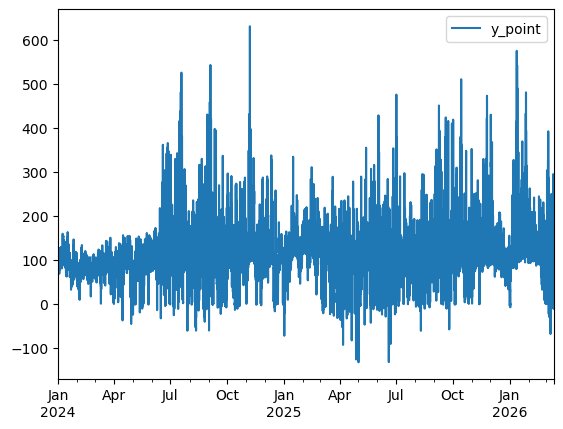

In [221]:
UNIFIED_15M_SPLINE[["y_point"]].plot()

In [222]:
UNIFIED_15M_SPLINE["load_fc"] = load_fc.reindex(UNIFIED_15M_SPLINE.index)
UNIFIED_15M_SPLINE["renewables_solar_fc"] = renewables_solar_fc.reindex(UNIFIED_15M_SPLINE.index)
UNIFIED_15M_SPLINE["renewables_wind_fc"] = renewables_wind_fc.reindex(UNIFIED_15M_SPLINE.index)

UNIFIED_15M_SPLINE

,y_point,is_synthetic,is_observed,load_fc,renewables_solar_fc,renewables_wind_fc
2024-01-01 00:00:00+01:00,76.690000,1,0,14899.0,0.0,2782.58
2024-01-01 00:15:00+01:00,76.217131,1,0,NaN,NaN,NaN
2024-01-01 00:30:00+01:00,75.788089,1,0,NaN,NaN,NaN
2024-01-01 00:45:00+01:00,75.320197,1,0,NaN,NaN,NaN
2024-01-01 01:00:00+01:00,74.500000,1,0,14425.0,0.0,2576.21
...,...,...,...,...,...,...
2026-03-13 22:45:00+01:00,116.880000,0,1,17600.0,0.0,5957.84
2026-03-13 23:00:00+01:00,133.690000,0,1,17350.0,0.0,5929.00
2026-03-13 23:15:00+01:00,107.840000,0,1,17000.0,0.0,5904.06
2026-03-13 23:30:00+01:00,108.840000,0,1,16650.0,0.0,5861.89


In [223]:
spline_ds = build_daily_dataset(UNIFIED_15M_SPLINE)
spline_ds = spline_ds.dropna(subset=FEATURE_COLS + ["y_target"]).copy()
spline_ds

,last_y,lag_1_t0,lag_4_t0,lag_8_t0,lag_24_t0,lag_96_t0,lag_192_t0,lag_672_t0,ramp_1h_t0,ramp_6h_t0,...,load_ramp_1h_target,load_ramp_6h_target,load_ramp_12h_target,load_day_mean,load_day_max,load_day_min,y_target,is_synthetic,is_observed,day
ts,,,,,,,,,,,,,,,,,,,,,
2024-01-16 00:00:00+01:00,84.121959,84.579049,86.140839,89.739366,109.746326,69.65,65.85,87.82,-2.01888,-25.624367,...,-1140.0,-5905.0,-6219.0,23924.833333,26804.0,18713.0,82.19,1,0,2024-01-16 00:00:00+01:00
2024-01-16 01:00:00+01:00,84.121959,84.579049,86.140839,89.739366,109.746326,66.05,64.23,90.68,-2.01888,-25.624367,...,-465.0,-6348.0,-6897.0,23924.833333,26804.0,18713.0,81.40,1,0,2024-01-16 00:00:00+01:00
2024-01-16 02:00:00+01:00,84.121959,84.579049,86.140839,89.739366,109.746326,64.31,64.14,90.19,-2.01888,-25.624367,...,-167.0,-6097.0,-6637.0,23924.833333,26804.0,18713.0,80.07,1,0,2024-01-16 00:00:00+01:00
2024-01-16 03:00:00+01:00,84.121959,84.579049,86.140839,89.739366,109.746326,62.04,64.88,90.70,-2.01888,-25.624367,...,83.0,-4694.0,-6410.0,23924.833333,26804.0,18713.0,79.60,1,0,2024-01-16 00:00:00+01:00
2024-01-16 04:00:00+01:00,84.121959,84.579049,86.140839,89.739366,109.746326,63.57,65.38,91.07,-2.01888,-25.624367,...,635.0,-2333.0,-6229.0,23924.833333,26804.0,18713.0,82.34,1,0,2024-01-16 00:00:00+01:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-13 22:45:00+01:00,89.600000,88.500000,91.820000,99.780000,209.450000,91.82,84.50,120.58,-2.22000,-119.850000,...,-950.0,-3500.0,-1750.0,18958.854167,21850.0,15450.0,116.88,0,1,2026-03-13 00:00:00+01:00
2026-03-13 23:00:00+01:00,89.600000,88.500000,91.820000,99.780000,209.450000,100.71,92.96,138.88,-2.22000,-119.850000,...,-1150.0,-3900.0,-2000.0,18958.854167,21850.0,15450.0,133.69,0,1,2026-03-13 00:00:00+01:00
2026-03-13 23:15:00+01:00,89.600000,88.500000,91.820000,99.780000,209.450000,83.90,84.50,129.28,-2.22000,-119.850000,...,-1250.0,-4400.0,-2350.0,18958.854167,21850.0,15450.0,107.84,0,1,2026-03-13 00:00:00+01:00


In [224]:
spline_ds = weight_df(spline_ds)
spline_ds

Zero daily_total: 0
Zero hourly_total: 23
Zero daily_avg: 0
Zero hourly_avg: 23


,last_y,lag_1_t0,lag_4_t0,lag_8_t0,lag_24_t0,lag_96_t0,lag_192_t0,lag_672_t0,ramp_1h_t0,ramp_6h_t0,...,daily_weight_lag_1w,hour_weight_lag_1d,hour_weight_lag_2d,hour_weight_lag_1w,daily_avg_weight_lag_1d,daily_avg_weight_lag_2d,daily_avg_weight_lag_1w,hour_avg_weight_lag_1d,hour_avg_weight_lag_2d,hour_avg_weight_lag_1w
ts,,,,,,,,,,,,,,,,,,,,,
2024-02-13 00:00:00+01:00,69.933089,70.293751,71.513663,76.032498,96.188248,73.16,67.82,60.08,-1.580574,-26.255159,...,0.027929,1.000000,1.000000,1.000000,0.886003,0.240958,0.670294,1.000000,1.000000,1.000000
2024-02-13 01:00:00+01:00,69.933089,70.293751,71.513663,76.032498,96.188248,74.25,57.98,55.74,-1.580574,-26.255159,...,0.027660,1.000000,1.000000,1.000000,0.869699,0.243342,0.663851,1.000000,1.000000,1.000000
2024-02-13 02:00:00+01:00,69.933089,70.293751,71.513663,76.032498,96.188248,74.16,56.81,53.60,-1.580574,-26.255159,...,0.027209,1.000000,1.000000,1.000000,0.869699,0.170325,0.653004,1.000000,1.000000,1.000000
2024-02-13 03:00:00+01:00,69.933089,70.293751,71.513663,76.032498,96.188248,74.25,56.39,53.21,-1.580574,-26.255159,...,0.027049,1.000000,1.000000,1.000000,0.887426,0.168686,0.649171,1.000000,1.000000,1.000000
2024-02-13 04:00:00+01:00,69.933089,70.293751,71.513663,76.032498,96.188248,74.90,56.41,54.56,-1.580574,-26.255159,...,0.027980,1.000000,1.000000,1.000000,0.903730,0.161235,0.671517,1.000000,1.000000,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-13 22:45:00+01:00,89.600000,88.500000,91.820000,99.780000,209.450000,91.82,84.50,120.58,-2.220000,-119.850000,...,0.011792,0.232509,0.215057,0.233433,0.821671,0.991597,1.132031,0.930035,0.860226,0.933733
2026-03-13 23:00:00+01:00,89.600000,88.500000,91.820000,99.780000,209.450000,100.71,92.96,138.88,-2.220000,-119.850000,...,0.013582,0.277660,0.282039,0.270300,0.901225,1.090874,1.303835,1.110639,1.128155,1.081199
2026-03-13 23:15:00+01:00,89.600000,88.500000,91.820000,99.780000,209.450000,83.90,84.50,129.28,-2.220000,-119.850000,...,0.012643,0.231314,0.256371,0.251615,0.750797,0.991597,1.213708,0.925257,1.025485,1.006462


In [225]:
column_nan_count = spline_ds.isnull().sum()
print("NaN count per column:")
print(column_nan_count)
total_nan_count = spline_ds.isnull().sum().sum()
print("Total NaN count:", total_nan_count)

NaN count per column:
last_y                     0
lag_1_t0                   0
lag_4_t0                   0
lag_8_t0                   0
lag_24_t0                  0
lag_96_t0                  0
lag_192_t0                 0
lag_672_t0                 0
ramp_1h_t0                 0
ramp_6h_t0                 0
ramp_1d_t0                 0
roll_mean_24_t0            0
roll_std_24_t0             0
roll_mean_96_t0            0
roll_std_96_t0             0
roll_mean_672_t0           0
roll_std_672_t0            0
h                          0
q_in_hour_target           0
qod_target                 0
hod_target                 0
dow_target                 0
month_target               0
is_weekend_target          0
q_in_hour_sin              0
q_in_hour_cos              0
qod_sin                    0
qod_cos                    0
hod_sin                    0
hod_cos                    0
dow_sin                    0
dow_cos                    0
month_sin                  0
month_cos            

In [226]:
spline_ds.to_csv(f"processed_data/{COUNTRY}/Spline_Processed_data_all.csv")

## Intra Pattern

In [227]:
pre_hour = pre_hour[["y_hour"]]
new_index = pd.date_range(
    start=pre_hour.index.min(),
    end=pre_hour.index.max() + pd.Timedelta(minutes=45),
    freq='15T',
    tz=pre_hour.index.tz
)

In [228]:
pre_hour = pre_hour[["y_hour"]]
df_15 = pre_hour.resample('15T').asfreq()
df_15 = pre_hour.reindex(new_index)
display(df_15)

,y_hour
2024-01-01 00:00:00+01:00,76.69
2024-01-01 00:15:00+01:00,NaN
2024-01-01 00:30:00+01:00,NaN
2024-01-01 00:45:00+01:00,NaN
2024-01-01 01:00:00+01:00,74.50
...,...
2025-09-30 22:45:00+02:00,NaN
2025-09-30 23:00:00+02:00,92.03
2025-09-30 23:15:00+02:00,NaN
2025-09-30 23:30:00+02:00,NaN


In [229]:
post_point

,y_real,is_synthetic,is_observed,y_point,y_p10,y_p50,y_p90
ts,,,,,,,
2025-10-01 00:00:00+02:00,98.95,0,1,98.95,NaN,NaN,NaN
2025-10-01 00:15:00+02:00,91.13,0,1,91.13,NaN,NaN,NaN
2025-10-01 00:30:00+02:00,81.79,0,1,81.79,NaN,NaN,NaN
2025-10-01 00:45:00+02:00,102.85,0,1,102.85,NaN,NaN,NaN
2025-10-01 01:00:00+02:00,93.98,0,1,93.98,NaN,NaN,NaN
...,...,...,...,...,...,...,...
2026-03-13 22:45:00+01:00,116.88,0,1,116.88,NaN,NaN,NaN
2026-03-13 23:00:00+01:00,133.69,0,1,133.69,NaN,NaN,NaN
2026-03-13 23:15:00+01:00,107.84,0,1,107.84,NaN,NaN,NaN


In [230]:
post_point['minute'] = post_point.index.minute

# average price per quarter-hour
pattern = post_point.groupby('minute')['y_real'].mean()

# normalize → mean = 1
pattern = pattern / pattern.mean()
pattern

minute
0     0.996672
15    1.001478
30    1.004811
45    0.997039
Name: y_real, dtype: float64

In [231]:

df_15['hourly'] = pre_hour['y_hour'].reindex(df_15.index, method='ffill')
df_15['minute'] = df_15.index.minute

df_15['pattern'] = df_15['minute'].map(pattern)

# generate 15-min values
df_15['y_point'] = df_15['hourly'] * df_15['pattern']
df_15

,y_hour,hourly,minute,pattern,y_point
2024-01-01 00:00:00+01:00,76.69,76.69,0,0.996672,76.434753
2024-01-01 00:15:00+01:00,NaN,76.69,15,1.001478,76.803385
2024-01-01 00:30:00+01:00,NaN,76.69,30,1.004811,77.058967
2024-01-01 00:45:00+01:00,NaN,76.69,45,0.997039,76.462894
2024-01-01 01:00:00+01:00,74.50,74.50,0,0.996672,74.252042
...,...,...,...,...,...
2025-09-30 22:45:00+02:00,NaN,100.65,45,0.997039,100.351941
2025-09-30 23:00:00+02:00,92.03,92.03,0,0.996672,91.723697
2025-09-30 23:15:00+02:00,NaN,92.03,15,1.001478,92.166065
2025-09-30 23:30:00+02:00,NaN,92.03,30,1.004811,92.472770


In [232]:
df_15 = df_15[["y_point"]]
df_15["is_synthetic"] = 1
df_15["is_observed"] = 0
df_15.rename(columns={"y_hour" : "y_point"}, inplace=True)
UNIFIED_15M_INTRAPATTERN = pd.concat([
    df_15[["y_point", "is_synthetic", "is_observed"]],
    post_point[["y_point", "is_synthetic", "is_observed"]],
]).sort_index()


In [233]:
UNIFIED_15M_INTRAPATTERN

,y_point,is_synthetic,is_observed
2024-01-01 00:00:00+01:00,76.434753,1,0
2024-01-01 00:15:00+01:00,76.803385,1,0
2024-01-01 00:30:00+01:00,77.058967,1,0
2024-01-01 00:45:00+01:00,76.462894,1,0
2024-01-01 01:00:00+01:00,74.252042,1,0
...,...,...,...
2026-03-13 22:45:00+01:00,116.880000,0,1
2026-03-13 23:00:00+01:00,133.690000,0,1
2026-03-13 23:15:00+01:00,107.840000,0,1
2026-03-13 23:30:00+01:00,108.840000,0,1


In [234]:
UNIFIED_15M_INTRAPATTERN["load_fc"] = load_fc.reindex(UNIFIED_15M_INTRAPATTERN.index)
UNIFIED_15M_INTRAPATTERN["renewables_solar_fc"] = renewables_solar_fc.reindex(UNIFIED_15M_INTRAPATTERN.index)
UNIFIED_15M_INTRAPATTERN["renewables_wind_fc"] = renewables_wind_fc.reindex(UNIFIED_15M_INTRAPATTERN.index)

UNIFIED_15M_INTRAPATTERN

,y_point,is_synthetic,is_observed,load_fc,renewables_solar_fc,renewables_wind_fc
2024-01-01 00:00:00+01:00,76.434753,1,0,14899.0,0.0,2782.58
2024-01-01 00:15:00+01:00,76.803385,1,0,NaN,NaN,NaN
2024-01-01 00:30:00+01:00,77.058967,1,0,NaN,NaN,NaN
2024-01-01 00:45:00+01:00,76.462894,1,0,NaN,NaN,NaN
2024-01-01 01:00:00+01:00,74.252042,1,0,14425.0,0.0,2576.21
...,...,...,...,...,...,...
2026-03-13 22:45:00+01:00,116.880000,0,1,17600.0,0.0,5957.84
2026-03-13 23:00:00+01:00,133.690000,0,1,17350.0,0.0,5929.00
2026-03-13 23:15:00+01:00,107.840000,0,1,17000.0,0.0,5904.06
2026-03-13 23:30:00+01:00,108.840000,0,1,16650.0,0.0,5861.89


In [235]:
intra_pattern_ds = build_daily_dataset(UNIFIED_15M_INTRAPATTERN)
intra_pattern_ds = intra_pattern_ds.dropna(subset=FEATURE_COLS + ["y_target"]).copy()
intra_pattern_ds

,last_y,lag_1_t0,lag_4_t0,lag_8_t0,lag_24_t0,lag_96_t0,lag_192_t0,lag_672_t0,ramp_1h_t0,ramp_6h_t0,...,load_ramp_1h_target,load_ramp_6h_target,load_ramp_12h_target,load_day_mean,load_day_max,load_day_min,y_target,is_synthetic,is_observed,day
ts,,,,,,,,,,,,,,,,,,,,,
2024-01-16 00:00:00+01:00,86.174051,86.845828,90.321732,92.674743,105.466749,69.418184,65.630832,87.527709,-4.147681,-19.292698,...,-1140.0,-5905.0,-6219.0,23924.833333,26804.0,18713.0,81.916447,1,0,2024-01-16 00:00:00+01:00
2024-01-16 01:00:00+01:00,86.174051,86.845828,90.321732,92.674743,105.466749,65.830166,64.016223,90.378190,-4.147681,-19.292698,...,-465.0,-6348.0,-6897.0,23924.833333,26804.0,18713.0,81.129077,1,0,2024-01-16 00:00:00+01:00
2024-01-16 02:00:00+01:00,86.174051,86.845828,90.321732,92.674743,105.466749,64.095957,63.926523,89.889821,-4.147681,-19.292698,...,-167.0,-6097.0,-6637.0,23924.833333,26804.0,18713.0,79.803503,1,0,2024-01-16 00:00:00+01:00
2024-01-16 03:00:00+01:00,86.174051,86.845828,90.321732,92.674743,105.466749,61.833512,64.664060,90.398123,-4.147681,-19.292698,...,83.0,-4694.0,-6410.0,23924.833333,26804.0,18713.0,79.335068,1,0,2024-01-16 00:00:00+01:00
2024-01-16 04:00:00+01:00,86.174051,86.845828,90.321732,92.674743,105.466749,63.358420,65.162396,90.766892,-4.147681,-19.292698,...,635.0,-2333.0,-6229.0,23924.833333,26804.0,18713.0,82.065948,1,0,2024-01-16 00:00:00+01:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-13 22:45:00+01:00,89.600000,88.500000,91.820000,99.780000,209.450000,91.820000,84.500000,120.580000,-2.220000,-119.850000,...,-950.0,-3500.0,-1750.0,18958.854167,21850.0,15450.0,116.880000,0,1,2026-03-13 00:00:00+01:00
2026-03-13 23:00:00+01:00,89.600000,88.500000,91.820000,99.780000,209.450000,100.710000,92.960000,138.880000,-2.220000,-119.850000,...,-1150.0,-3900.0,-2000.0,18958.854167,21850.0,15450.0,133.690000,0,1,2026-03-13 00:00:00+01:00
2026-03-13 23:15:00+01:00,89.600000,88.500000,91.820000,99.780000,209.450000,83.900000,84.500000,129.280000,-2.220000,-119.850000,...,-1250.0,-4400.0,-2350.0,18958.854167,21850.0,15450.0,107.840000,0,1,2026-03-13 00:00:00+01:00


In [236]:
intra_pattern_ds = weight_df(intra_pattern_ds)
intra_pattern_ds

Zero daily_total: 0
Zero hourly_total: 187
Zero daily_avg: 0
Zero hourly_avg: 187


,last_y,lag_1_t0,lag_4_t0,lag_8_t0,lag_24_t0,lag_96_t0,lag_192_t0,lag_672_t0,ramp_1h_t0,ramp_6h_t0,...,daily_weight_lag_1w,hour_weight_lag_1d,hour_weight_lag_2d,hour_weight_lag_1w,daily_avg_weight_lag_1d,daily_avg_weight_lag_2d,daily_avg_weight_lag_1w,hour_avg_weight_lag_1d,hour_avg_weight_lag_2d,hour_avg_weight_lag_1w
ts,,,,,,,,,,,,,,,,,,,,,
2024-02-13 00:00:00+01:00,72.454799,73.019626,75.007218,83.671484,93.003766,72.916502,67.594275,59.880036,-2.552419,-20.548967,...,0.027929,1.000000,1.000000,1.000000,0.886003,0.240958,0.670294,1.000000,1.000000,1.000000
2024-02-13 01:00:00+01:00,72.454799,73.019626,75.007218,83.671484,93.003766,74.002874,57.787025,55.554481,-2.552419,-20.548967,...,0.027660,1.000000,1.000000,1.000000,0.869699,0.243342,0.663851,1.000000,1.000000,1.000000
2024-02-13 02:00:00+01:00,72.454799,73.019626,75.007218,83.671484,93.003766,73.913174,56.620919,53.421603,-2.552419,-20.548967,...,0.027209,1.000000,1.000000,1.000000,0.869699,0.170325,0.653004,1.000000,1.000000,1.000000
2024-02-13 03:00:00+01:00,72.454799,73.019626,75.007218,83.671484,93.003766,74.002874,56.202317,53.032901,-2.552419,-20.548967,...,0.027049,1.000000,1.000000,1.000000,0.887426,0.168686,0.649171,1.000000,1.000000,1.000000
2024-02-13 04:00:00+01:00,72.454799,73.019626,75.007218,83.671484,93.003766,74.650711,56.222251,54.378408,-2.552419,-20.548967,...,0.027980,1.000000,1.000000,1.000000,0.903730,0.161235,0.671517,1.000000,1.000000,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-13 22:45:00+01:00,89.600000,88.500000,91.820000,99.780000,209.450000,91.820000,84.500000,120.580000,-2.220000,-119.850000,...,0.011792,0.232509,0.215057,0.233433,0.821671,0.991597,1.132031,0.930035,0.860226,0.933733
2026-03-13 23:00:00+01:00,89.600000,88.500000,91.820000,99.780000,209.450000,100.710000,92.960000,138.880000,-2.220000,-119.850000,...,0.013582,0.277660,0.282039,0.270300,0.901225,1.090874,1.303835,1.110639,1.128155,1.081199
2026-03-13 23:15:00+01:00,89.600000,88.500000,91.820000,99.780000,209.450000,83.900000,84.500000,129.280000,-2.220000,-119.850000,...,0.012643,0.231314,0.256371,0.251615,0.750797,0.991597,1.213708,0.925257,1.025485,1.006462


In [237]:
column_nan_count = intra_pattern_ds.isnull().sum()
print("NaN count per column:")
print(column_nan_count)
total_nan_count = intra_pattern_ds.isnull().sum().sum()
print("Total NaN count:", total_nan_count)

NaN count per column:
last_y                     0
lag_1_t0                   0
lag_4_t0                   0
lag_8_t0                   0
lag_24_t0                  0
lag_96_t0                  0
lag_192_t0                 0
lag_672_t0                 0
ramp_1h_t0                 0
ramp_6h_t0                 0
ramp_1d_t0                 0
roll_mean_24_t0            0
roll_std_24_t0             0
roll_mean_96_t0            0
roll_std_96_t0             0
roll_mean_672_t0           0
roll_std_672_t0            0
h                          0
q_in_hour_target           0
qod_target                 0
hod_target                 0
dow_target                 0
month_target               0
is_weekend_target          0
q_in_hour_sin              0
q_in_hour_cos              0
qod_sin                    0
qod_cos                    0
hod_sin                    0
hod_cos                    0
dow_sin                    0
dow_cos                    0
month_sin                  0
month_cos            

In [238]:
intra_pattern_ds.to_csv(f"processed_data/{COUNTRY}/Intra_Pattern_Processed_data_all.csv")